In [3]:
import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import sem
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

# Set up plotting style
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")


In [4]:
# Configuration for paw speed
base_path = "/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results"
# base_path = "/home/lenny-aharon/IBL results decoding/ibl-mouse/ibl-mouse_neural-activity/results"


eids = [
    "15b69921-d471-4ded-8814-2adad954bcd8",    
    "15763234-d21e-491f-a01b-1238eb96d389", 
    "aad23144-0e52-4eac-80c5-c4ee2decb198",
    "9b528ad0-4599-4a55-9148-96cc1d93fb24",
    "4b00df29-3769-43be-bb40-128b1cba6d35",
    # "0841d188-8ef2-4f20-9828-76a94d5343a4", # resnet is doing better than MVT - we can still have it if we decide 23 sessions for decoding 
    "f312aaec-3b6f-44b3-86b4-3a0c119c0438",
    "0f77ca5d-73c2-45bd-aa4c-4c5ed275dbde",
    "1b715600-0cbc-442c-bd00-5b0ac2865de1",
    
    # "3bcb81b4-d9ca-4fc9-a1cd-353a966239ca", # not looking good. consider removing
    # "03d9a098-07bf-4765-88b7-85f8d8f620cc", # very bad with EKS 
    "3e6a97d3-3991-49e2-b346-6948cb4580fb",
    "3f859b5c-e73a-4044-b49e-34bb81e96715", # bad with EKS 
    "4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b",
    "5ae68c54-2897-4d3a-8120-426150704385",
    "5dcee0eb-b34d-4652-acc3-d10afc6eae68",
    # "6c6b0d06-6039-4525-a74b-58cfaa1d3a60", # I used to comment out - in general can remove but will decide later 
    "7cb81727-2097-4b52-b480-c89867b5b34c",
    "8a3a0197-b40a-449f-be55-c00b23253bbf",
    "30c4e2ab-dffc-499d-aae4-e51d6b3218c2",
    "51e53aff-1d5d-4182-a684-aba783d50ae5",
    # "61e11a11-ab65-48fb-ae08-3cb80662e5d6", # bad with EKS 
    "746d1902-fa59-4cab-b0aa-013be36060d5",
    "824cf03d-4012-4ab1-b499-c83a92c5589e",

    "3638d102-e8b6-4230-8742-e548cd87a949",
    "6899a67d-2e53-4215-a52a-c7021b5da5d4",
    "8928f98a-b411-497e-aa4b-aa752434686d",

    "46794e05-3f6a-4d35-afb3-9165091a5a74", 
    "493170a6-fd94-4ee4-884f-cc018c17eeb9", 
    "54238fd6-d2d0-4408-b1a9-d19d24fd29ce", 
    "73918ae1-e4fd-4c18-b132-00cb555b1ad2", # not great for MVT
    "b03fbc44-3d8e-4a6c-8a50-5ea3498568e0", 
    # # "b196a2ad-511b-4e90-ac99-b5a29ad25c22", # not great camera parameters 
    "b22f694e-4a34-4142-ab9d-2556c3487086", 
    "c7248e09-8c0d-40f2-9eb4-700a8973d8c8", 
    "c7bf2d49-4937-4597-b307-9f39cb1c7b16", 
    "ca4ecb4c-4b60-4723-9b9e-2c54a6290a53", 
    "d0ea3148-948d-4817-94f8-dcaf2342bbbe", 
    "d23a44ef-1402-4ed7-97f5-47e9a7a504d9", 
    # # "db4df448-e449-4a6f-a0e7-288711e7a75a", # this is a bad session with variance or something like this 
    "dc962048-89bb-4e6a-96a9-b062a2be1426", 
    "e535fb62-e245-4a48-b119-88ce62a6fe67", 
    "f115196e-8dfe-4d2a-8af3-8206d93c1729", 
    "f140a2ec-fd49-4814-994a-fe3476f14e66", 
    "f3ce3197-d534-4618-bf81-b687555d1883", 
    "ff96bfe1-d925-4553-94b5-bf8297adf259",

    # This 2 sessions need to be removed
    # "71e55bfe-5a3a-4cba-bdc7-f085140d798e",
    # "754b74d5-7a06-4004-ae0c-72a10b6ed2e6",
    # "5c0c560e-9e1f-45e9-b66e-e4ee7855be84",
]

# eid = "0841d188-8ef2-4f20-9828-76a94d5343a4"
eid = "15763234-d21e-491f-a01b-1238eb96d389" # this is a good session
# eid = "7cb81727-2097-4b52-b480-c89867b5b34c"
# eid = "f140a2ec-fd49-4814-994a-fe3476f14e66"

# target = "lightning-pose-left-pawL-speed"  # The paw speed target we decoded
# target = "lightning-pose-right-pawL-speed"  # The paw speed target we decoded
# target = "lightning-pose-left-pawR-speed"  # The paw speed target we decoded
# target = "lightning-pose-right-pawR-speed"  # The paw speed target we decoded
# target = "lightning-pose-pawL-3d-speed"  # The paw speed target we decoded
target = "lightning-pose-pawR-3d-speed" 

model = "linear"
# model = "reduced_rank"

# Define the two pose models to compare
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median", "MVT_3d_aug_patch_eks_linear"]
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median", "MVT_3d_aug_patch_eks_linear", "resnet50_eks_linear"]
# pose_models = ["resnet50_median", "MVT_3d_aug_patch_median", "MVT_3d_aug_patch_median_400"]
# pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new", "MVT_3d_aug_patch_eks_linear_new"]
# pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new", "MVT_3d_aug_patch_eks_linear_new", "resnet50_anipose_new"]

# pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new", "MVT_3d_aug_patch_eks_linear_new"]
# pose_models = ["resnet50_median_new", "MVT_3d_loss_patch_median_new", "MVT_3d_aug_patch_eks_linear_new"]
# pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new", "MVT_3d_loss_patch_median_new"]

# pose_models = ["resnet50_median_new",  "resnet50_anipose_new", "MVT_3d_aug_patch_median_new", "MVT_3d_aug_patch_eks_linear_new"]
# pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new", "MVT_3d_aug_patch_eks_linear_new"]
pose_models = ["resnet50_median_new", "MVT_3d_aug_patch_median_new", "MVT_3d_aug_patch_eks_linear_new"]





In [5]:
import os
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def load_session_results(base_path, eid, target, pose_models, model_method="linear"):
    """
    Loads cross-validation results for multiple pose models.
    Automatically detects and flattens all coordinate and variance data,
    including 3D triangulation and multi-view keys.
    """
    results = {}
    
    for pose_model in pose_models:
        results_path = f"{base_path}/{eid}/{target}/{pose_model}/{model_method}/all/{eid}_cv.npy"
        
        if not os.path.exists(results_path):
            print(f"Warning: Results not found at {results_path}")
            continue
            
        print(f"\n{'='*40}")
        print(f"Loading: {pose_model}")
        
        # Load the data dictionary
        data = np.load(results_path, allow_pickle=True).item()
        
        # 1. Core Speed Data
        test_y = data['all_test_y']
        test_pred = data['all_test_pred']
        y_flat = test_y.flatten()
        pred_flat = test_pred.flatten()
                
        # 2. Initialize result container for this model
        res = {
            'test_y': test_y,
            'test_pred': test_pred,
            'y_flattened': y_flat,
            'pred_flattened': pred_flat,
            'test_metric': data['overall_metric'],
            'r2': r2_score(y_flat, pred_flat),
            'mse': mean_squared_error(y_flat, pred_flat),
            'correlation': np.corrcoef(y_flat, pred_flat)[0, 1],
            # Mapping Info
            'test_frame_indices': data.get('all_test_frame_indices'),
            'test_original_trial_ids': data.get('all_test_original_trial_indices')
        }
        
        # 3. Dynamic Ensemble/Coordinate extraction
        # This will automatically pick up: x_ens_var, left_x_ens_var, x_3d, etc.
        ens_data = data.get('all_test_ens_vars', {})
        for key, val in ens_data.items():
            if val is not None:
                res[key] = val
                res[f"{key}_flattened"] = val.flatten()
        
        # Load all available ensemble/coordinate data
        ens_data = data.get('all_test_ens_vars', {})
        for key, val in ens_data.items():
            if val is not None:
                res[key] = val
                res[f"{key}_flattened"] = val.flatten()
        
        # --- CALCULATE UNIFIED AVERAGE VARIANCE ---
        # CASE A: 2D Target (has x_ens_var and y_ens_var)
        if 'x_ens_var' in res and 'y_ens_var' in res:
            avg_var = (res['x_ens_var'] + res['y_ens_var']) / 2
            res['avg_ens_var_flattened'] = avg_var.flatten()
            
        # CASE B: 3D Target (has left_x_ens_var, right_x_ens_var, etc.)
        elif 'left_x_ens_var' in res and 'right_x_ens_var' in res:
            # Average across all 4 components (Left X, Left Y, Right X, Right Y)
            all_vars = [res['left_x_ens_var'], res['left_y_ens_var'], 
                        res['right_x_ens_var'], res['right_y_ens_var']]
            avg_var = sum(all_vars) / 4
            res['avg_ens_var_flattened'] = avg_var.flatten()

        results[pose_model] = res
        
        # Print summary
        print(f"  Target: {target}")
        print(f"  Session: {eid}")
        print(f"  Trials: {len(res['test_original_trial_ids']) if res['test_original_trial_ids'] is not None else 'Unknown'}")
        print(f"  R² (flattened): {res['r2']:.3f}")
        
        # List what was extracted (for debugging)
        extracted_keys = [k for k in ens_data.keys() if ens_data[k] is not None]
        if extracted_keys:
            print(f"  Extracted vars: {', '.join(extracted_keys)}")

    return results

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Collect data into a list of records
records = []
for eid1 in eids:
    results = load_session_results(base_path, eid1, target, pose_models, model_method=model)
    for pose_model in pose_models:
        if pose_model in results:
            records.append({
                'Session': eid1,
                'Model': pose_model,
                'R2': results[pose_model]['r2']
            })

df_results = pd.DataFrame(records)


Loading: resnet50_median_new
  Target: lightning-pose-pawR-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.173
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawR-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.135
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawR-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.200
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

In [19]:
r2_values_sessions = []
for eid1 in eids:
    results = load_session_results(base_path, eid1, target, pose_models,model_method=model)
    
    # Extract R² values for each pose model in this session
    for pose_model in pose_models:
        if pose_model in results:
            r2_values_sessions.append(results[pose_model]['r2'])

# Calculate average R² across all sessions for each pose model
r2_by_model = {}
for eid1 in eids:
    results = load_session_results(base_path, eid1, target, pose_models, model_method=model)
    
    # Extract R² values for each pose model in this session
    for pose_model in pose_models:
        if pose_model in results:
            if pose_model not in r2_by_model:
                r2_by_model[pose_model] = []
            r2_by_model[pose_model].append(results[pose_model]['r2'])

# Print average R² for each pose model
print(f"\nAverage R² across all sessions by pose model:")
print(f" the target is {target}")
for pose_model in pose_models:
    if pose_model in r2_by_model and r2_by_model[pose_model]:
        avg_r2 = np.mean(r2_by_model[pose_model])
        std_r2 = np.std(r2_by_model[pose_model])
        print(f"  {pose_model}: {avg_r2:.3f} ± {std_r2:.3f} (n={len(r2_by_model[pose_model])})")
    else:
        print(f"  {pose_model}: No data found")



Loading: resnet50_median_new
  Target: lightning-pose-pawR-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.173
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawR-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.135
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawR-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.200
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

In [20]:
# Print average R² for each pose model
print(f"\nAverage R² across all sessions by pose model:")
print(f" the target is {target}")
for pose_model in pose_models:
    if pose_model in r2_by_model and r2_by_model[pose_model]:
        avg_r2 = np.mean(r2_by_model[pose_model])
        std_r2 = np.std(r2_by_model[pose_model])
        sem_r2 = std_r2 / np.sqrt(len(r2_by_model[pose_model]))
        if pose_model == "MVT_3d_aug_patch_median_new":
            pose_model_name = "LP3D"
        else:
            pose_model_name = pose_model
        print(f"  {pose_model_name}: {avg_r2:.3f} ± {sem_r2:.3f} (n={len(r2_by_model[pose_model])})")
        # print(f"  {pose_model}: {avg_r2:.3f} ± {std_r2:.3f} (n={len(r2_by_model[pose_model])})")
    else:
        print(f"  {pose_model}: No data found")




Average R² across all sessions by pose model:
 the target is lightning-pose-pawR-3d-speed
  resnet50_median_new: 0.209 ± 0.012 (n=39)
  LP3D: 0.216 ± 0.011 (n=39)
  MVT_3d_aug_patch_eks_linear_new: 0.287 ± 0.013 (n=39)



ONE-SIDED STATISTICAL TEST (Baseline: resnet50_median_new)
  MVT_3d_aug_patch_median_new > resnet50_median_new: p-value = 1.8921e-05
  MVT_3d_aug_patch_eks_linear_new > resnet50_median_new: p-value = 1.8190e-12


/tmp/ipykernel_2952671/3147526002.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Model', y='R2', order=model_order,
/tmp/ipykernel_2952671/3147526002.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='Model', y='R2', order=model_order,


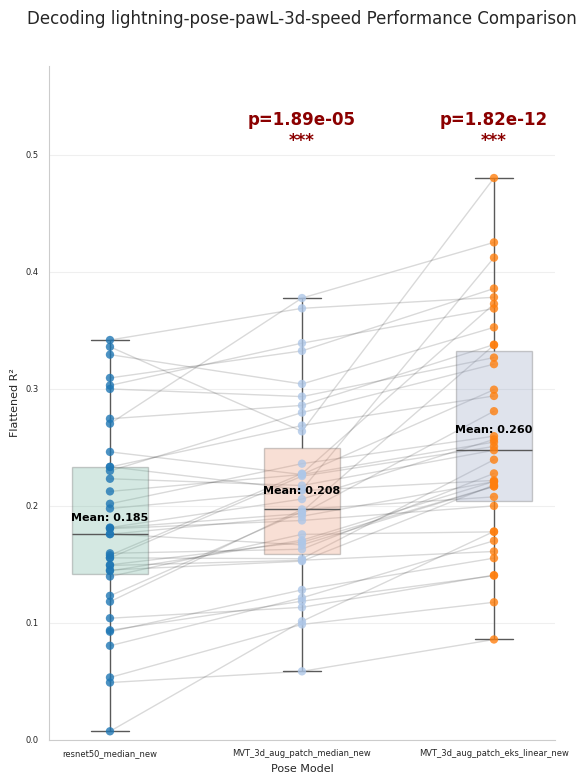

In [131]:
from scipy.stats import wilcoxon
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_session_comparison_with_stats(df, title="Model Performance Across Sessions"):
    """
    Plots IQR boxes with individual session dots and connecting lines.
    Performs one-sided Wilcoxon tests against the baseline (first model).
    """
    plt.figure(figsize=(6, 8))
    
    # 1. Setup Models and Pivot Data
    model_order = list(df['Model'].unique())
    baseline_model = model_order[0]
    pivot_df = df.pivot(index='Session', columns='Model', values='R2').dropna()
    
    # 2. Draw the IQR Boxes (Boxplot)
    # showfliers=False hides outliers so they don't double-plot with stripplot
    sns.boxplot(data=df, x='Model', y='R2', order=model_order, 
                palette='Set2', showfliers=False, width=0.4, boxprops=dict(alpha=0.3))
    
    # 3. Draw the Individual Session Points
    sns.stripplot(data=df, x='Model', y='R2', order=model_order, 
                  size=6, jitter=False, palette='tab20', alpha=0.8)

    # 4. Draw Connecting Lines (Paired comparison)
    x_coords = range(len(model_order))
    for _, row in pivot_df.iterrows():
        y_values = [row[m] for m in model_order]
        plt.plot(x_coords, y_values, color='black', alpha=0.15, linestyle='-', linewidth=1, zorder=0)

    # 5. Statistical Testing & Annotation
    print(f"\n{'='*60}")
    print(f"ONE-SIDED STATISTICAL TEST (Baseline: {baseline_model})")
    print(f"{'='*60}")
    
    y_max = df['R2'].max()
    
    for i, model in enumerate(model_order):
        # Calculate Mean for display
        avg_r2 = df[df['Model'] == model]['R2'].mean()
        plt.text(i, avg_r2, f'Mean: {avg_r2:.3f}', ha='center', va='bottom', 
                 fontsize=8, fontweight='bold', color='black')
        
        # Perform Stats against Baseline (skip the baseline itself)
        if model != baseline_model:
            # alternative='greater' tests if the current model > baseline
            _, p_val = wilcoxon(pivot_df[model], pivot_df[baseline_model], alternative='greater')
            
            print(f"  {model} > {baseline_model}: p-value = {p_val:.4e}")
            
            # Add p-value text to the plot
            stars = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
            plt.text(i, y_max * 1.05, f"p={p_val:.2e}\n{stars}", 
                     ha='center', va='bottom', color='darkred', fontweight='bold')
    

    plt.title(title, fontsize=12, pad=30)
    plt.ylabel("Flattened R²", fontsize=8)
    plt.xlabel("Pose Model", fontsize=8)
    plt.ylim(0, y_max * 1.2) # Make room for the p-values at the top
    plt.grid(axis='y', alpha=0.3)
    
    # Set x-axis tick label font size
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)
    
    # Remove legend since we're not showing session names
    sns.despine()
    plt.tight_layout()
    plt.show()

# Run the updated function
plot_session_comparison_with_stats(df_results, title=f"Decoding {target} Performance Comparison")


ONE-SIDED STATISTICAL TESTS
  MVT_3d_aug_patch_median_new > resnet50_median_new: p-value = 1.8921e-05
  MVT_3d_aug_patch_eks_linear_new > resnet50_median_new: p-value = 1.8190e-12
  MVT_3d_aug_patch_eks_linear_new > MVT_3d_aug_patch_median_new: p-value = 1.8190e-12


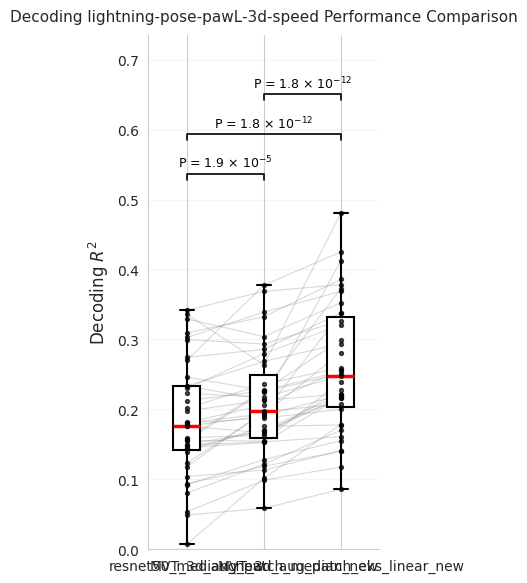

In [ ]:
# from scipy.stats import wilcoxon
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# import os

# def plot_session_comparison_with_stats(df, title="Model Performance Across Sessions", save_path=None):
#     """
#     Plots IQR boxes with individual session dots and connecting lines.
#     Styled to match reference figure: black/white boxes, red median, gray lines, bracket p-values.
#     """
#     fig, ax = plt.subplots(figsize=(4, 6))

#     model_order = list(df['Model'].unique())
#     baseline_model = model_order[0]
#     pivot_df = df.pivot(index='Session', columns='Model', values='R2').dropna()
#     n_models = len(model_order)
#     x_positions = np.arange(n_models)

#     # 1. Draw Connecting Lines (behind everything)
#     for _, row in pivot_df.iterrows():
#         y_values = [row[m] for m in model_order]
#         ax.plot(x_positions, y_values, color='gray', alpha=0.3, linestyle='-', linewidth=0.8, zorder=1)

#     # 2. Draw Boxplots — black outline, white fill, red median
#     bp = ax.boxplot(
#         [pivot_df[m].values for m in model_order],
#         positions=x_positions,
#         widths=0.35,
#         patch_artist=True,
#         medianprops=dict(color='red', linewidth=2.5),
#         boxprops=dict(facecolor='white', color='black', linewidth=1.5),
#         whiskerprops=dict(color='black', linewidth=1.5),
#         capprops=dict(color='black', linewidth=1.5),
#         flierprops=dict(marker='', linestyle='none'),
#         zorder=2
#     )

#     # 3. Draw Individual Session Points (black dots, no jitter)
#     for i, model in enumerate(model_order):
#         y_vals = pivot_df[model].values
#         x_vals = np.full_like(y_vals, i, dtype=float)
#         ax.scatter(x_vals, y_vals, color='black', s=8, alpha=0.7, zorder=3)

#     # 4. Statistical Annotation with Brackets
#     print(f"\n{'='*60}")
#     print(f"ONE-SIDED STATISTICAL TESTS")
#     print(f"{'='*60}")

#     y_max = df['R2'].max()
#     y_range = y_max - df['R2'].min()
#     bracket_step = y_range * 0.12

#     # Define comparisons: each non-baseline vs baseline, then second vs third
#     comparisons = []
#     for i, model in enumerate(model_order):
#         if model == baseline_model:
#             continue
#         comparisons.append((0, i))

#     # Pairwise: second vs third
#     if n_models >= 3:
#         comparisons.append((1, 2))

#     bracket_levels = []
#     for (x1, x2) in comparisons:
#         m1, m2 = model_order[x1], model_order[x2]
#         _, p_val = wilcoxon(pivot_df[m2], pivot_df[m1], alternative='greater')
#         print(f"  {m2} > {m1}: p-value = {p_val:.4e}")

#         level = len(bracket_levels)
#         y_bracket = y_max + bracket_step * (level + 1)
#         bracket_levels.append(y_bracket)

#         tick_height = bracket_step * 0.15
#         ax.plot([x1, x1, x2, x2],
#                 [y_bracket - tick_height, y_bracket, y_bracket, y_bracket - tick_height],
#                 color='black', linewidth=1.2, zorder=4)

#         exp = int(f'{p_val:.1e}'.split('e')[1])
#         mantissa = float(f'{p_val:.1e}'.split('e')[0])
#         p_text = f'P = {mantissa} × 10$^{{{exp}}}$'

#         ax.text((x1 + x2) / 2, y_bracket + tick_height * 0.5,
#                 p_text, ha='center', va='bottom', fontsize=9, color='black')

#     # 5. Axes formatting
#     ax.set_xticks(x_positions)
#     ax.set_xticklabels(model_order, fontsize=11)
#     ax.set_ylabel("Decoding $R^2$", fontsize=12)
#     ax.set_xlabel("")
#     ax.set_ylim(0, y_max + bracket_step * (len(bracket_levels) + 1.5))
#     ax.set_xlim(-0.5, n_models - 0.5)

#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.tick_params(axis='both', labelsize=10)
#     ax.grid(axis='y', alpha=0.2)

#     plt.title(title, fontsize=11, pad=10)
#     plt.tight_layout()
    
#     # Save figure if path is provided
#     if save_path:
#         os.makedirs(os.path.dirname(save_path), exist_ok=True)
#         plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
#         print(f"Figure saved to: {save_path}")
    
#     plt.show()

# # Create save path and run the function
# save_path = f"/home/lenny-aharon/neural_decoding/notebooks/figures_lenny/decoding_{target}_performance_comparison.pdf"
# plot_session_comparison_with_stats(df_results, title=f"Decoding {target} Performance Comparison", save_path=None)


ONE-SIDED STATISTICAL TESTS
  MVT_3d_aug_patch_median_new > resnet50_median_new: p-value = 1.8921e-05
  MVT_3d_aug_patch_eks_linear_new > resnet50_median_new: p-value = 1.8190e-12
  MVT_3d_aug_patch_eks_linear_new > MVT_3d_aug_patch_median_new: p-value = 1.8190e-12
Figure saved to: /home/lenny-aharon/neural_decoding/notebooks/figures_lenny/decoding_lightning-pose-pawL-3d-speed_performance_comparison.pdf


/tmp/ipykernel_2952671/937459118.py:165: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


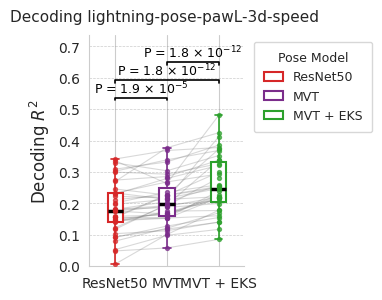

In [133]:
from scipy.stats import wilcoxon
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

def plot_session_comparison_with_stats(df, title="Model Performance Across Sessions", save_path=None):
    """
    Plots IQR boxes with individual session dots and connecting lines.
    Styled to match reference figure: white fill, colored outline per model,
    red median, gray connecting lines, bracket p-values.
    """

    # -------------------------
    # Color & label definitions
    # -------------------------
    model_labels = {
        'resnet50_median_new':             'ResNet50',
        'MVT_3d_aug_patch_median_new':     'MVT',
        'MVT_3d_aug_patch_eks_linear_new': 'MVT + EKS',
        'resnet50_anipose_new':            'ResNet50 + Anipose',
    }

    model_colors = {
        'resnet50_median_new':             '#d62728',
        'MVT_3d_aug_patch_median_new':     '#7b2d8b',
        'MVT_3d_aug_patch_eks_linear_new': '#2ca02c',
        'resnet50_anipose_new':            '#ff7f0e',
    }

    fig, ax = plt.subplots(figsize=(2, 3))

    model_order   = list(df['Model'].unique())
    baseline_model = model_order[0]
    pivot_df      = df.pivot(index='Session', columns='Model', values='R2').dropna()
    n_models      = len(model_order)
    x_positions   = np.arange(n_models)

    # Readable x-tick labels
    x_labels = [model_labels.get(m, m) for m in model_order]

    # -------------------------
    # 1. Connecting lines
    # -------------------------
    for _, row in pivot_df.iterrows():
        y_values = [row[m] for m in model_order]
        ax.plot(x_positions, y_values, color='gray', alpha=0.3,
                linestyle='-', linewidth=0.8, zorder=1)

    # -------------------------
    # 2. Boxplots — white fill, colored outline, red median
    # -------------------------
    bp = ax.boxplot(
        [pivot_df[m].values for m in model_order],
        positions=x_positions,
        widths=0.30,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2.5),
        boxprops=dict(facecolor='white', linewidth=1.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='', linestyle='none'),
        zorder=2
    )

    # Apply per-model color to box, whiskers, caps
    for idx, m in enumerate(model_order):
        color = model_colors.get(m, 'black')

        bp['boxes'][idx].set_edgecolor(color)

        bp['whiskers'][idx * 2].set_color(color)
        bp['whiskers'][idx * 2 + 1].set_color(color)

        bp['caps'][idx * 2].set_color(color)
        bp['caps'][idx * 2 + 1].set_color(color)

    # -------------------------
    # 3. Individual session dots (colored per model)
    # -------------------------
    for i, m in enumerate(model_order):
        y_vals = pivot_df[m].values
        x_vals = np.full_like(y_vals, i, dtype=float)
        ax.scatter(x_vals, y_vals,
                   color=model_colors.get(m, 'black'),
                   s=8, alpha=0.7, zorder=3)

    # -------------------------
    # 4. Statistical brackets
    # -------------------------
    print(f"\n{'='*60}")
    print(f"ONE-SIDED STATISTICAL TESTS")
    print(f"{'='*60}")

    y_max        = df['R2'].max()
    y_range      = y_max - df['R2'].min()
    bracket_step = y_range * 0.12

    comparisons = []
    for i, model in enumerate(model_order):
        if model != baseline_model:
            comparisons.append((0, i))
    if n_models >= 3:
        comparisons.append((1, 2))

    bracket_levels = []
    for (x1, x2) in comparisons:
        m1, m2  = model_order[x1], model_order[x2]
        _, p_val = wilcoxon(pivot_df[m2], pivot_df[m1], alternative='greater')
        print(f"  {m2} > {m1}: p-value = {p_val:.4e}")

        level      = len(bracket_levels)
        y_bracket  = y_max + bracket_step * (level + 1)
        tick_height = bracket_step * 0.15
        bracket_levels.append(y_bracket)

        ax.plot([x1, x1, x2, x2],
                [y_bracket - tick_height, y_bracket, y_bracket, y_bracket - tick_height],
                color='black', linewidth=1.2, zorder=4)

        exp      = int(f'{p_val:.1e}'.split('e')[1])
        mantissa = float(f'{p_val:.1e}'.split('e')[0])
        p_text   = f'P = {mantissa} × 10$^{{{exp}}}$'

        ax.text((x1 + x2) / 2, y_bracket + tick_height * 0.5,
                p_text, ha='center', va='bottom', fontsize=9, color='black')

    # -------------------------
    # 5. Axes formatting
    # -------------------------
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_ylabel("Decoding $R^2$", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylim(0, y_max + bracket_step * (len(bracket_levels) + 1.5))
    ax.set_xlim(-0.5, n_models - 0.5)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    ax.tick_params(axis='both', labelsize=10)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='gray')
    ax.set_axisbelow(True)

    # -------------------------
    # 6. Legend (outside right)
    # -------------------------
    handles = [
        mpatches.Patch(facecolor='white',
                       edgecolor=model_colors.get(m, 'black'),
                       linewidth=1.5,
                       label=model_labels.get(m, m))
        for m in model_order
    ]
    ax.legend(handles=handles,
              title='Pose Model', title_fontsize=9,
              fontsize=9, frameon=True, framealpha=0.9,
              edgecolor='lightgray',
              bbox_to_anchor=(1.02, 1), loc='upper left',
              borderpad=0.8, handlelength=1.5)

    plt.title(title, fontsize=11, pad=10)
    plt.tight_layout()

    # -------------------------
    # 7. Save
    # -------------------------
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Figure saved to: {save_path}")

    plt.show()


# --- Usage ---
save_path = f"/home/lenny-aharon/neural_decoding/notebooks/figures_lenny/decoding_{target}_performance_comparison.pdf"
plot_session_comparison_with_stats(
    df_results,
    title=f"Decoding {target} ",
    save_path=save_path
)

In [134]:
# Define colors for each pose model
# Darker color for pose model (ground truth), lighter for decoded prediction
colors = {

    'MVT_3d_aug_patch_median_new': {
        'pose': '#1f77b4',      # Dark blue
        'decoded': '#aec7e8'    # Light blue
    },
    'resnet50_median_new': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    },

    'resnet50_anipose_new': {
        'pose': '#d62728',      # Dark red
        'decoded': '#ff9896'    # Light red/pink
    },

    'MVT_3d_aug_patch_eks_linear_new': {
        'pose': 'green',      
        'decoded': 'lightgreen'    
    },

    
}

In [135]:
def diagnose_low_variance_bins(base_path, eids, target, pose_models, n_bins=10):
    """
    Diagnose why low variance bins have negative R².
    """
    agg_data = {m: {'y': [], 'pred': [], 'var': []} for m in pose_models}
    
    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        for m in pose_models:
            if m in res_dict and 'avg_ens_var_flattened' in res_dict[m]:
                agg_data[m]['y'].append(res_dict[m]['y_flattened'])
                agg_data[m]['pred'].append(res_dict[m]['pred_flattened'])
                agg_data[m]['var'].append(res_dict[m]['avg_ens_var_flattened'])
    
    # Concatenate
    for m in pose_models:
        agg_data[m]['y'] = np.concatenate(agg_data[m]['y'])
        agg_data[m]['pred'] = np.concatenate(agg_data[m]['pred'])
        agg_data[m]['var'] = np.concatenate(agg_data[m]['var'])
    
    shared_vars = [agg_data[m]['var'] for m in pose_models]
    shared_var_scale = np.mean(shared_vars, axis=0)
    
    percentiles = np.linspace(0, 100, n_bins + 1)
    thresholds = np.percentile(shared_var_scale, percentiles)
    thresholds[-1] += 1e-9
    
    m = pose_models[0]  # Check first model
    
    print("=== Diagnosis by Variance Bin ===\n")
    print(f"{'Bin':<10} {'N':<8} {'Mean Y':<10} {'Std Y':<10} {'Mean Pred':<10} {'R²':<10}")
    print("-" * 60)
    
    for j in range(n_bins):
        mask = (shared_var_scale >= thresholds[j]) & (shared_var_scale < thresholds[j+1])
        
        y_bin = agg_data[m]['y'][mask]
        pred_bin = agg_data[m]['pred'][mask]
        
        if len(y_bin) < 2:
            continue
        
        r2 = r2_score(y_bin, pred_bin)
        
        print(f"{j*10}-{(j+1)*10}%    {len(y_bin):<8} {np.mean(y_bin):<10.4f} {np.std(y_bin):<10.4f} {np.mean(pred_bin):<10.4f} {r2:<10.4f}")


diagnose_low_variance_bins(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

  Target: lightning-pose-pawL-3d-speed
  Session: 9b528ad0-4599-4a55-9148-96cc1d93fb24
  Trials: 340
  R² (flattened): 0.159
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 9b528ad0-4599-4a55-9148-96cc1d93fb24
  Trials: 340
  R² (flattened): 0.163
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 9b528ad0-4599-4a55-9148-96cc1d93fb24
  Trials: 340
  R² (flattened): 0.228
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_new
  Target: lightning-pose-p

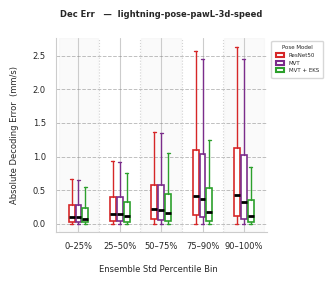

In [136]:
def plot_error_boxplots_by_percentile_optimized(
        base_path, eids, target, pose_models,
        percentile_bins=[0, 25, 50, 75, 90, 100],
        save_pdf=False, pdf_path=None):

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    unit_label = "mm/s" if "3d" in target.lower() else "pix/s"

    # -------------------------
    # 1. Collect data
    # -------------------------
    all_data = {m: {'error': [], 'ens_std': []} for m in pose_models}

    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        if not all(m in res_dict and 'avg_ens_var_flattened' in res_dict[m]
                   for m in pose_models):
            continue
        for m in pose_models:
            res     = res_dict[m]
            error   = np.abs(res['y_flattened'] - res['pred_flattened'])
            var     = res['avg_ens_var_flattened']
            ens_std = np.sqrt(np.maximum(var, 0))
            all_data[m]['error'].append(error)
            all_data[m]['ens_std'].append(ens_std)

    for m in pose_models:
        all_data[m]['error']   = np.concatenate(all_data[m]['error'])
        all_data[m]['ens_std'] = np.concatenate(all_data[m]['ens_std'])

    # -------------------------
    # 2. Shared uncertainty axis
    # -------------------------
    ens_std_stack = np.stack([all_data[m]['ens_std'] for m in pose_models], axis=0)
    avg_ens_std   = np.mean(ens_std_stack, axis=0)
    percentile_thresholds = np.percentile(avg_ens_std, percentile_bins)

    # -------------------------
    # 3. Color & label definitions
    # -------------------------
    labels = {
        'resnet50_median_new':             'ResNet50',
        'MVT_3d_aug_patch_median_new':     'MVT',
        'MVT_3d_aug_patch_eks_linear_new': 'MVT + EKS',
        'resnet50_anipose_new':            'ResNet50 + Anipose',
    }

    colors = {
        'resnet50_median_new':             '#d62728',
        'MVT_3d_aug_patch_median_new':     '#7b2d8b',
        'MVT_3d_aug_patch_eks_linear_new': '#2ca02c',
        'resnet50_anipose_new':            '#ff7f0e',
    }

    # -------------------------
    # 4. Build boxplot data
    # -------------------------
    boxplot_data      = []
    boxplot_positions = []
    boxplot_colors    = []

    width   = 0.15   # thinner boxes
    spacing = 0.9
    bin_centers = []

    for i in range(len(percentile_bins) - 1):
        t_low  = percentile_thresholds[i]
        t_high = percentile_thresholds[i + 1]
        mask   = (avg_ens_std >= t_low) & (avg_ens_std < t_high)
        center = i * spacing
        bin_centers.append(center)

        for j, m in enumerate(pose_models):
            errors   = all_data[m]['error'][mask]
            position = center + (j - (len(pose_models) - 1) / 2) * width
            boxplot_data.append(errors)
            boxplot_positions.append(position)
            boxplot_colors.append(colors.get(m, 'gray'))

    # -------------------------
    # 5. Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(3.5, 3))

    # Subtle alternating bin shading
    for i, center in enumerate(bin_centers):
        if i % 2 == 0:
            ax.axvspan(center - spacing * 0.48, center + spacing * 0.48,
                       color='gray', alpha=0.04, zorder=0)

    bp = ax.boxplot(
        boxplot_data,
        positions=boxplot_positions,
        widths=width * 0.85,
        patch_artist=True,
        showfliers=False,
        zorder=2,
        # Red median line like the reference figure
        medianprops=dict(color='black', linewidth=2.0),
        # Whiskers and caps match box color — set per-box below
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
        boxprops=dict(linewidth=1.2),
    )

    # Empty fill (white), colored outline + whiskers/caps per model
    n_models   = len(pose_models)
    n_bins     = len(percentile_bins) - 1
    n_boxes    = n_bins * n_models

    for idx in range(n_boxes):
        color = boxplot_colors[idx]

        # Box: white fill, colored border
        bp['boxes'][idx].set_facecolor('white')
        bp['boxes'][idx].set_edgecolor(color)

        # Whiskers (2 per box)
        bp['whiskers'][idx * 2].set_color(color)
        bp['whiskers'][idx * 2 + 1].set_color(color)

        # Caps (2 per box)
        bp['caps'][idx * 2].set_color(color)
        bp['caps'][idx * 2 + 1].set_color(color)

    # Vertical separator lines between bins
    for i in range(len(bin_centers) - 1):
        x_sep = (bin_centers[i] + bin_centers[i + 1]) / 2
        ax.axvline(x_sep, color='lightgray', linewidth=0.8,
                   linestyle=':', zorder=1)

    # -------------------------
    # 6. Axes formatting
    # -------------------------
    bin_labels = [
        f"{percentile_bins[i]}–{percentile_bins[i+1]}%"
        for i in range(len(percentile_bins) - 1)
    ]

    ax.set_xticks(bin_centers)
    ax.set_xticklabels(bin_labels, fontsize=6)
    ax.set_xlabel("Ensemble Std Percentile Bin  ",
                  fontsize=6, labelpad=10)
    ax.set_ylabel(f"Absolute Decoding Error  ({unit_label})",
                  fontsize=6, labelpad=10)
    ax.set_title(f"Dec Err   —  {target}",
                 fontsize=6, fontweight='bold', pad=15)

    # Set tick label font sizes
    ax.tick_params(axis='x', labelsize=6)
    ax.tick_params(axis='y', labelsize=6)

    ax.set_xlim(bin_centers[0] - spacing * 0.55,
                bin_centers[-1] + spacing * 0.55)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.5, color='gray')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

    # -------------------------
    # 7. Legend (outside right)
    # -------------------------
    handles = [
        mpatches.Patch(facecolor='white',
                       edgecolor=colors.get(m, 'gray'),
                       linewidth=1.5,
                       label=labels.get(m, m))
        for m in pose_models
    ]
    ax.legend(handles=handles,
              title='Pose Model', title_fontsize=4,
              fontsize=4, frameon=True, framealpha=0.9,
              edgecolor='lightgray',
              bbox_to_anchor=(1.01, 1), loc='upper left',
              borderpad=0.8, handlelength=1.5)

    plt.tight_layout()

    # -------------------------
    # 8. Save PDF if requested
    # -------------------------
    if save_pdf:
        if pdf_path is None:
            pdf_path = f"error_boxplots_by_uncertainty_{target.replace(' ', '_')}.pdf"
        fig.savefig(pdf_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Plot saved as: {pdf_path}")

    return fig


save_path = "/home/lenny-aharon/neural_decoding/notebooks/figures_lenny"
fig = plot_error_boxplots_by_percentile_optimized(
    base_path, eids, target, pose_models,
    save_pdf=True,
    pdf_path=os.path.join(save_path, f"error_boxplots_by_uncertainty_{target.replace(' ', '_')}.pdf")
)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 3e6a97d3-3991-49e2-b346-6948cb4580fb
  Trials: 374
  R² (flattened): 0.181
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 3e6a97d3-3991-49e2-b346-6948cb4580fb
  Trials: 374
  R² (flattened): 0.206
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 3e6a97d3-3991-49e2-b346-6948cb4580fb
  Trials: 374
  R² (flattened): 0.257
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

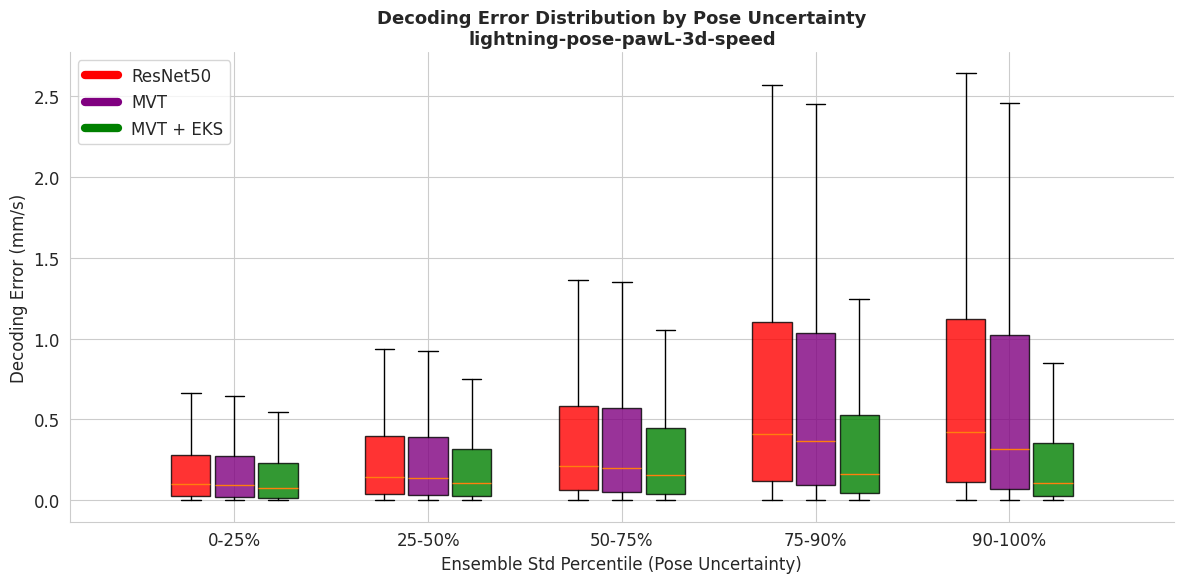

In [ ]:
# def plot_error_boxplots_by_percentile_optimized(
#         base_path, eids, target, pose_models,
#         percentile_bins=[0, 25, 50, 75, 90, 100],
#         save_pdf=False, pdf_path=None):

#     import numpy as np
#     import matplotlib.pyplot as plt

#     unit_label = "mm/s" if "3d" in target.lower() else "pix/s"

#     # -------------------------
#     # 1. Collect data
#     # -------------------------
#     all_data = {m: {'error': [], 'ens_std': []} for m in pose_models}

#     for eid in eids:

#         res_dict = load_session_results(base_path, eid, target, pose_models)

#         if not all(m in res_dict and 'avg_ens_var_flattened' in res_dict[m]
#                    for m in pose_models):
#             continue

#         for m in pose_models:

#             res = res_dict[m]

#             error = np.abs(res['y_flattened'] - res['pred_flattened'])

#             var = res['avg_ens_var_flattened']

#             ens_std = np.sqrt(np.maximum(var, 0))

#             all_data[m]['error'].append(error)
#             all_data[m]['ens_std'].append(ens_std)

#     # concatenate once
#     for m in pose_models:

#         all_data[m]['error'] = np.concatenate(all_data[m]['error'])
#         all_data[m]['ens_std'] = np.concatenate(all_data[m]['ens_std'])

#     # -------------------------
#     # 2. Shared uncertainty axis
#     # -------------------------
#     ens_std_stack = np.stack(
#         [all_data[m]['ens_std'] for m in pose_models], axis=0)

#     avg_ens_std = np.mean(ens_std_stack, axis=0)

#     percentile_thresholds = np.percentile(avg_ens_std, percentile_bins)

#     # -------------------------
#     # 3. Build boxplot data (efficient)
#     # -------------------------
#     boxplot_data = []
#     boxplot_positions = []
#     boxplot_colors = []

#     labels = {
#         'resnet50_median_new': 'ResNet50',
#         'MVT_3d_aug_patch_median_new': 'MVT',
#         'MVT_3d_aug_patch_eks_linear_new': 'MVT + EKS',
#         'resnet50_anipose_new': 'ResNet50 + Anipose',
#     }

#     colors = {
#         'resnet50_median_new': 'red',
#         'MVT_3d_aug_patch_median_new': 'purple',
#         'MVT_3d_aug_patch_eks_linear_new': 'green',
#         'resnet50_anipose_new': 'orange',
#     }

#     width = 0.18
#     spacing = 0.8

#     bin_centers = []

#     for i in range(len(percentile_bins)-1):

#         t_low = percentile_thresholds[i]
#         t_high = percentile_thresholds[i+1]

#         mask = (avg_ens_std >= t_low) & (avg_ens_std < t_high)

#         center = i * spacing
#         bin_centers.append(center)

#         for j, m in enumerate(pose_models):

#             errors = all_data[m]['error'][mask]

#             position = center + (j - (len(pose_models)-1)/2)*width

#             boxplot_data.append(errors)
#             boxplot_positions.append(position)
#             boxplot_colors.append(colors.get(m, "gray"))

#     # -------------------------
#     # 4. Plot
#     # -------------------------
#     fig, ax = plt.subplots(figsize=(12,6))

#     bp = ax.boxplot(
#         boxplot_data,
#         positions=boxplot_positions,
#         widths=width*0.9,
#         patch_artist=True,
#         showfliers=False
#     )

#     # color boxes
#     for patch, color in zip(bp['boxes'], boxplot_colors):

#         patch.set_facecolor(color)
#         patch.set_alpha(0.8)

#     # -------------------------
#     # 5. Labels and legend
#     # -------------------------
#     bin_labels = [
#         f"{percentile_bins[i]}-{percentile_bins[i+1]}%"
#         for i in range(len(percentile_bins)-1)
#     ]

#     ax.set_xticks(bin_centers)
#     ax.set_xticklabels(bin_labels)

#     ax.set_xlabel(
#         "Ensemble Std Percentile (Pose Uncertainty)",
#         fontsize=12,
#         fontweight='medium'
#     )

#     ax.set_ylabel(
#         f"Decoding Error ({unit_label})",
#         fontsize=12,
#         fontweight='medium'
#     )

#     ax.set_title(
#         f"Decoding Error Distribution by Pose Uncertainty\n{target}",
#         fontsize=13,
#         fontweight='bold'
#     )

#     # legend
#     handles = [
#         plt.Line2D([0], [0], color=colors[m], lw=6)
#         for m in pose_models
#     ]

#     ax.legend(
#         handles,
#         [labels.get(m, m) for m in pose_models],
#         frameon=True
#     )

#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

#     plt.tight_layout()

#     # -------------------------
#     # 6. Save PDF if requested
#     # -------------------------
#     if save_pdf:
#         if pdf_path is None:
#             pdf_path = f"error_boxplots_by_uncertainty_{target.replace(' ', '_')}.pdf"
#         fig.savefig(pdf_path, format='pdf', bbox_inches='tight', dpi=300)
#         print(f"Plot saved as: {pdf_path}")

#     return fig

# save_path = "/home/lenny-aharon/neural_decoding/notebooks/figures_lenny"
# fig = plot_error_boxplots_by_percentile_optimized(base_path, eids, target, pose_models, save_pdf=False, pdf_path=os.path.join(save_path, f"error_boxplots_by_uncertainty_{target.replace(' ', '_')}.pdf"))


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

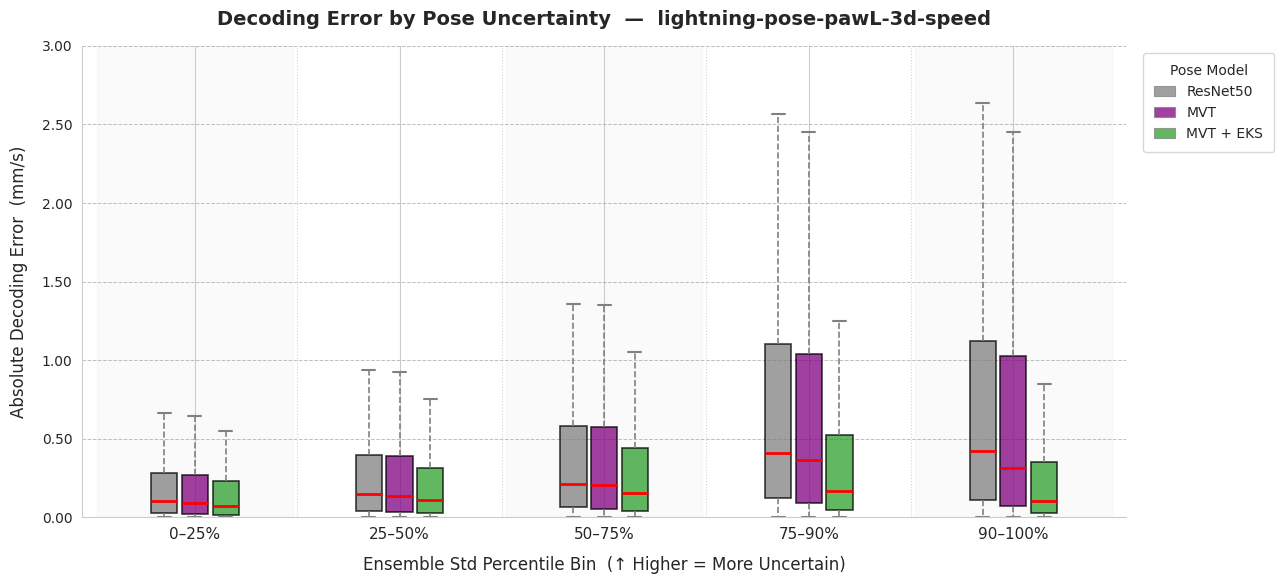

In [67]:
def plot_error_boxplots_by_percentile_optimized(
        base_path, eids, target, pose_models,
        percentile_bins=[0, 25, 50, 75, 90, 100],
        color_key='pose'):

    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    unit_label = "mm/s" if "3d" in target.lower() else "pix/s"

    # -------------------------
    # 1. Collect data
    # -------------------------
    all_data = {m: {'error': [], 'ens_std': []} for m in pose_models}

    for eid in eids:
        res_dict = load_session_results(base_path, eid, target, pose_models)
        if not all(m in res_dict and 'avg_ens_var_flattened' in res_dict[m]
                   for m in pose_models):
            continue
        for m in pose_models:
            res = res_dict[m]
            error = np.abs(res['y_flattened'] - res['pred_flattened'])
            var = res['avg_ens_var_flattened']
            ens_std = np.sqrt(np.maximum(var, 0))
            all_data[m]['error'].append(error)
            all_data[m]['ens_std'].append(ens_std)

    for m in pose_models:
        all_data[m]['error'] = np.concatenate(all_data[m]['error'])
        all_data[m]['ens_std'] = np.concatenate(all_data[m]['ens_std'])

    # -------------------------
    # 2. Shared uncertainty axis
    # -------------------------
    ens_std_stack = np.stack([all_data[m]['ens_std'] for m in pose_models], axis=0)
    avg_ens_std = np.mean(ens_std_stack, axis=0)
    percentile_thresholds = np.percentile(avg_ens_std, percentile_bins)

    # -------------------------
    # 3. Color & label definitions
    # -------------------------
    labels = {
        'resnet50_median_new':              'ResNet50',
        'MVT_3d_aug_patch_median_new':      'MVT',
        'MVT_3d_aug_patch_eks_linear_new':  'MVT + EKS',
        'resnet50_anipose_new':             'ResNet50 + Anipose',
    }

    color_map = {
        'MVT_3d_aug_patch_median_new': {
            'pose':    'purple',
            'decoded': '#ce9fdb'
        },
        'resnet50_median_new': {
            'pose':    'gray',
            'decoded': '#ff9896'
        },
        'resnet50_anipose_new': {
            'pose':    'orange',
            'decoded': '#ff9896'
        },
        'MVT_3d_aug_patch_eks_linear_new': {
            'pose':    '#2ca02c',
            'decoded': '#98df8a'
        },
    }

    # -------------------------
    # 4. Build boxplot data
    # -------------------------
    boxplot_data      = []
    boxplot_positions = []
    boxplot_colors    = []

    width   = 0.15
    spacing = 1.0
    bin_centers = []

    for i in range(len(percentile_bins) - 1):
        t_low  = percentile_thresholds[i]
        t_high = percentile_thresholds[i + 1]
        mask   = (avg_ens_std >= t_low) & (avg_ens_std < t_high)
        center = i * spacing
        bin_centers.append(center)

        for j, m in enumerate(pose_models):
            errors   = all_data[m]['error'][mask]
            position = center + (j - (len(pose_models) - 1) / 2) * width
            boxplot_data.append(errors)
            boxplot_positions.append(position)
            boxplot_colors.append(color_map.get(m, {}).get(color_key, 'gray'))

    # -------------------------
    # 5. Plot
    # -------------------------
    fig, ax = plt.subplots(figsize=(13, 6))

    # Subtle alternating bin shading
    for i, center in enumerate(bin_centers):
        half = spacing * 0.48
        if i % 2 == 0:
            ax.axvspan(center - half, center + half, color='gray', alpha=0.04, zorder=0)

    bp = ax.boxplot(
        boxplot_data,
        positions=boxplot_positions,
        widths=width * 0.85,
        patch_artist=True,
        showfliers=False,
        zorder=2,
        medianprops=dict(linewidth=2),
        whiskerprops=dict(linewidth=1.2, linestyle='--', color='gray'),
        capprops=dict(linewidth=1.5, color='gray'),
        boxprops=dict(linewidth=1.2),
    )

    for patch, color in zip(bp['boxes'], boxplot_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Make median lines white so they stand out on colored boxes
    for median in bp['medians']:
        median.set_color('red')
        median.set_linewidth(2)

    # Vertical separator lines between bins
    for i in range(len(bin_centers) - 1):
        x_sep = (bin_centers[i] + bin_centers[i + 1]) / 2
        ax.axvline(x_sep, color='lightgray', linewidth=0.8, linestyle=':', zorder=1)

    # -------------------------
    # 6. Axes formatting
    # -------------------------
    bin_labels = [
        f"{percentile_bins[i]}–{percentile_bins[i+1]}%"
        for i in range(len(percentile_bins) - 1)
    ]

    ax.set_xticks(bin_centers)
    ax.set_xticklabels(bin_labels, fontsize=11)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels([f'{y:.2f}' for y in ax.get_yticks()], fontsize=10)

    ax.set_xlabel("Ensemble Std Percentile Bin  (↑ Higher = More Uncertain)",
                  fontsize=12, labelpad=10)
    ax.set_ylabel(f"Absolute Decoding Error  ({unit_label})",
                  fontsize=12, labelpad=10)
    ax.set_title(f"Decoding Error by Pose Uncertainty  —  {target}",
                 fontsize=14, fontweight='bold', pad=15)

    ax.set_xlim(bin_centers[0] - spacing * 0.55, bin_centers[-1] + spacing * 0.55)
    ax.set_ylim(0)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.5, color='gray')
    ax.set_axisbelow(True)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

    # -------------------------
    # 7. Legend (outside right)
    # -------------------------
    handles = [
        mpatches.Patch(
            facecolor=color_map.get(m, {}).get(color_key, 'gray'),
            edgecolor='gray',
            linewidth=0.8,
            alpha=0.75,
            label=labels.get(m, m)
        )
        for m in pose_models
    ]

    ax.legend(
        handles=handles,
        title='Pose Model',
        title_fontsize=10,
        fontsize=10,
        frameon=True,
        framealpha=0.9,
        edgecolor='lightgray',
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        borderpad=0.8,
        handlelength=1.5,
    )

    plt.tight_layout()
    return fig

fig = plot_error_boxplots_by_percentile_optimized(base_path, eids, target, pose_models, color_key='pose')


DETAILED PERFORMANCE SUMMARY: lightning-pose-pawL-3d-speed

MODEL STATISTICS (Mean ± STD):
                                      MAE           Correlation          
                                     mean       std        mean       std
Model                                                                    
MVT_3d_aug_patch_eks_linear_new  0.317271  0.222800    0.504596  0.092074
MVT_3d_aug_patch_median_new      0.507892  0.409874    0.450324  0.084902
resnet50_median_new              0.531533  0.387466    0.420229  0.103100

PAIRED STATISTICAL TESTS (Wilcoxon Signed-Rank):
n = 39 common sessions

>>> Hypothesis: MVT_3d_aug_patch_median_new is BETTER than resnet50_median_new
  One-sided p-val (Corr MVT_3d_aug_patch_median_new > resnet50_median_new): 1.1898e-05
  One-sided p-val (MAE MVT_3d_aug_patch_median_new < resnet50_median_new):  1.1212e-03
  Result: SIGNIFICANT

>>> Hypothesis: MVT_3d_aug_patch_eks_linear_new is BETTER than resnet50_median_new
  One-sided p-val (Corr MVT_3d_

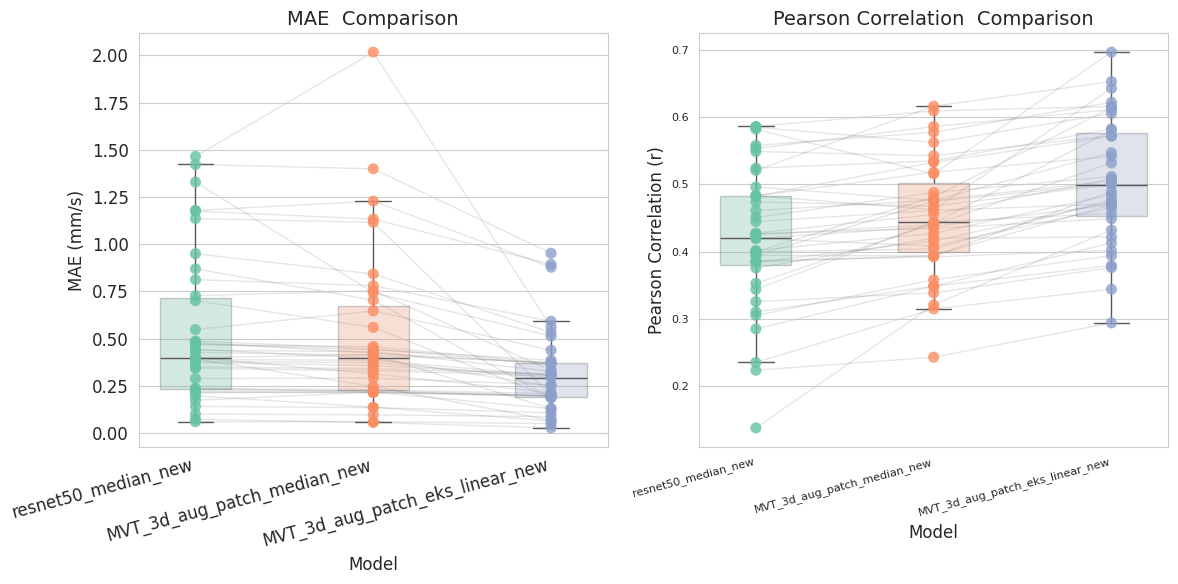

In [68]:
from scipy.stats import wilcoxon
from itertools import combinations

def plot_session_summary_with_detailed_stats(base_path, eids, target, pose_models):
    records = []
    for eid in eids:
        for m_name in pose_models:
            path = f"{base_path}/{eid}/{target}/{m_name}/linear/all/{eid}_cv.npy"
            if not os.path.exists(path): continue
            data = np.load(path, allow_pickle=True).item()
            y, pred = data['all_test_y'].flatten(), data['all_test_pred'].flatten()
            records.append({
                'Session': eid, 
                'Model': m_name, 
                'MAE': np.mean(np.abs(y - pred)), 
                'Correlation': np.corrcoef(y, pred)[0, 1]
            })
    
    df = pd.DataFrame(records)
    pivot_mae = df.pivot(index='Session', columns='Model', values='MAE').dropna()
    pivot_corr = df.pivot(index='Session', columns='Model', values='Correlation').dropna()
    available_models = [m for m in pose_models if m in pivot_mae.columns]

    # --- 1. PRINT NUMERICAL VALUES TO CONSOLE ---
    print(f"\n{'='*70}")
    print(f"DETAILED PERFORMANCE SUMMARY: {target}")
    print(f"{'='*70}")
    
    summary = df.groupby('Model')[['MAE', 'Correlation']].agg(['mean', 'std'])
    print("\nMODEL STATISTICS (Mean ± STD):")
    print(summary)

    # --- 2. MULTI-MODEL STATISTICAL TESTS ---
    if len(available_models) >= 2:
        print(f"\nPAIRED STATISTICAL TESTS (Wilcoxon Signed-Rank):")
        print(f"n = {len(pivot_mae)} common sessions")
        
        # Iterate through all possible pairs of models
        for m1, m2 in combinations(available_models, 2):
            print(f"\n>>> Hypothesis: {m2} is BETTER than {m1}")
            
            # 1. Correlation: Test if m2 > m1
            _, p_corr_one = wilcoxon(pivot_corr[m2], pivot_corr[m1], alternative='greater')
            
            # 2. MAE: Test if m2 < m1
            _, p_mae_one = wilcoxon(pivot_mae[m2], pivot_mae[m1], alternative='less')
            
            print(f"  One-sided p-val (Corr {m2} > {m1}): {p_corr_one:.4e}")
            print(f"  One-sided p-val (MAE {m2} < {m1}):  {p_mae_one:.4e}")
            
            # Add a significance indicator for quick reading
            sig = "SIGNIFICANT" if p_corr_one < 0.05 else "NOT SIGNIFICANT"
            print(f"  Result: {sig}")
    print(f"{'='*70}\n")

    # --- 3. GENERATE PLOTS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    metrics = ['MAE', 'Correlation']
    axes = [ax1, ax2]
    ylabels = ["MAE (mm/s)", "Pearson Correlation (r)"]
    # font of the x-axis labels
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    pivots = [pivot_mae, pivot_corr]

    for ax, metric, ylabel, p_df in zip(axes, metrics, ylabels, pivots):
        # Fix for the FutureWarning: assign hue=Model
        sns.boxplot(data=df, x='Model', y=metric, hue='Model', ax=ax, palette='Set2', 
                    showfliers=False, width=0.4, boxprops=dict(alpha=0.3), legend=False)
        sns.stripplot(data=df, x='Model', y=metric, hue='Model', ax=ax, palette='Set2', 
                      size=8, alpha=0.8, jitter=False, legend=False)
        
        # Draw Connecting Lines for all models
        x_coords = range(len(available_models))
        for _, row in p_df.iterrows():
            ax.plot(x_coords, [row[m] for m in available_models], color='black', alpha=0.1, lw=1, zorder=0)

        ax.set_title(f"{ylabel.split('(')[0]} Comparison", fontsize=14)
        ax.set_ylabel(ylabel)
        plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

    plt.tight_layout()
    plt.show()

# Execute
plot_session_summary_with_detailed_stats(base_path, eids, target, pose_models)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.176
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.167
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15b69921-d471-4ded-8814-2adad954bcd8
  Trials: 390
  R² (flattened): 0.216
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: resnet50_median_

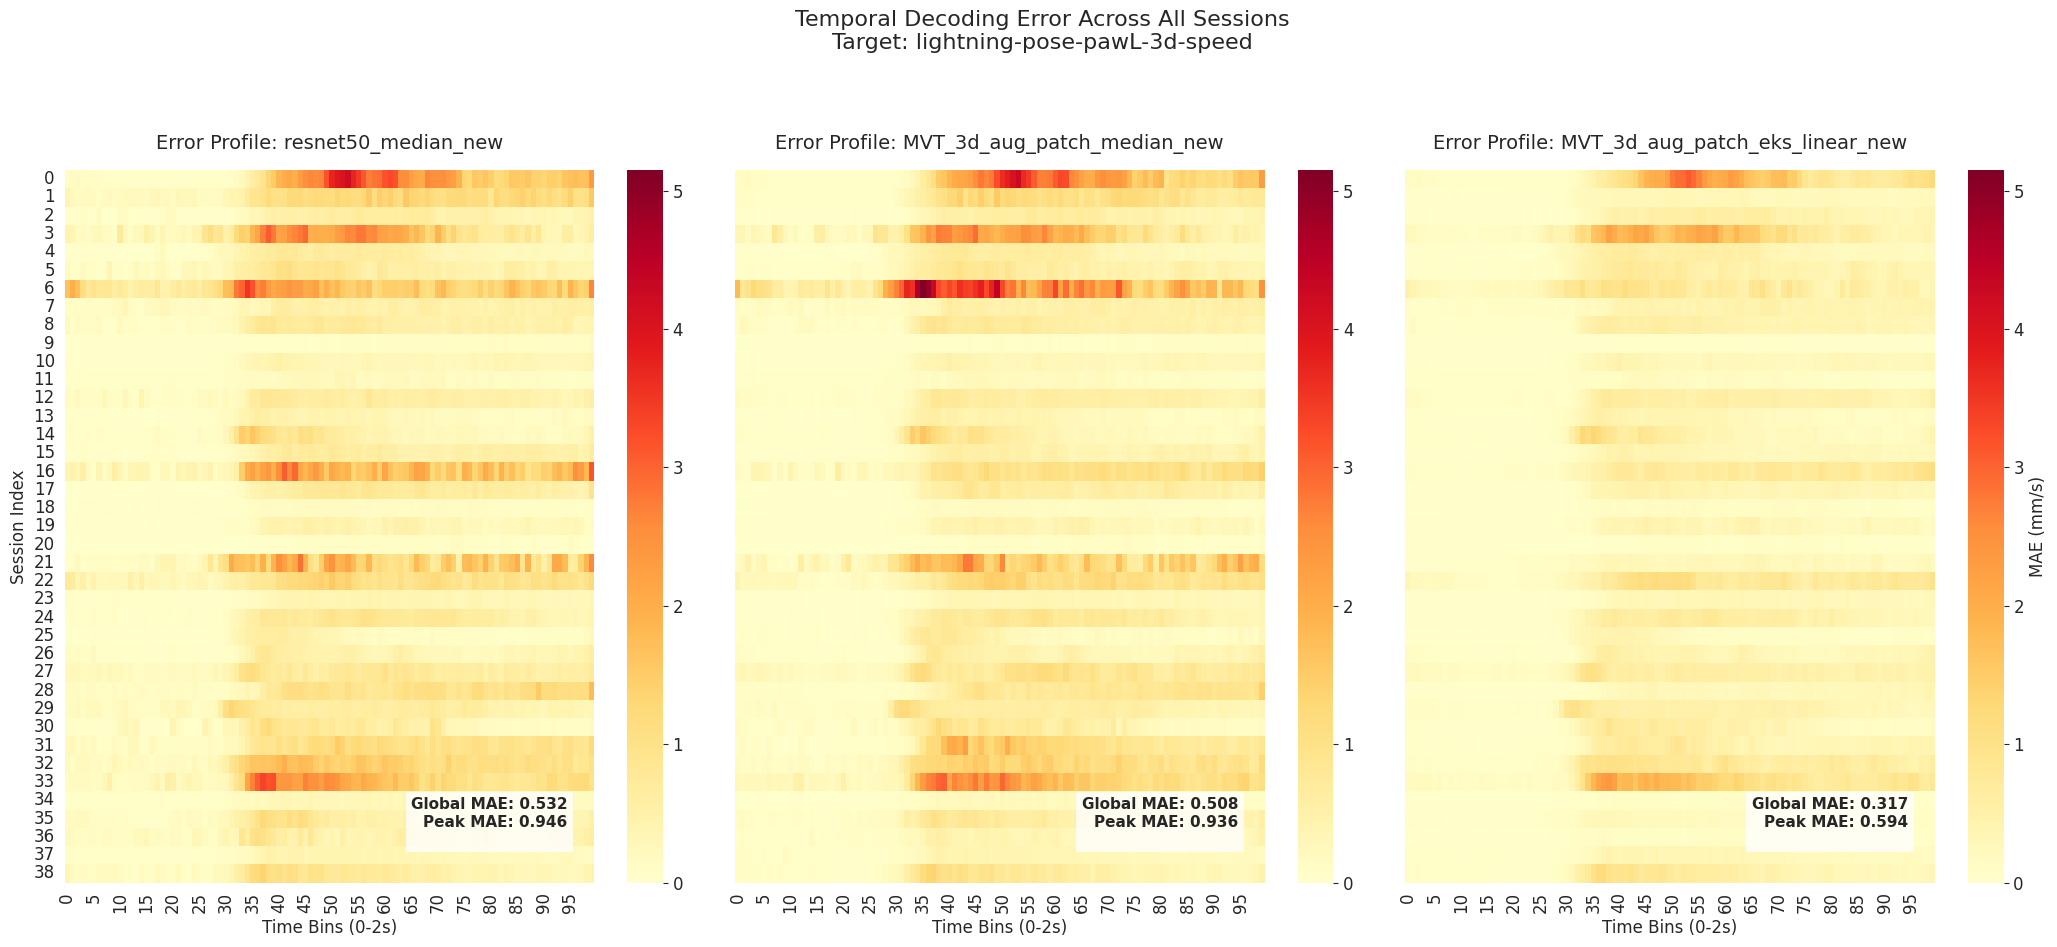

In [69]:
def plot_error_heatmap_across_sessions(base_path, eids, target, pose_models):
    """
    Plots MAE heatmaps with shared color scale and summary statistics.
    """
    n_models = len(pose_models)
    model_data = {m: [] for m in pose_models}
    global_max = 0
    
    # 1. Collect Data
    for eid in eids:
        for m_name in pose_models:
            res_dict = load_session_results(base_path, eid, target, [m_name])
            if m_name in res_dict:
                err = np.mean(np.abs(res_dict[m_name]['test_y'] - res_dict[m_name]['test_pred']), axis=0)
                model_data[m_name].append(err)
                global_max = max(global_max, np.max(err))
    
    # 2. Plot
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 9), sharey=True)
    if n_models == 1: axes = [axes]
    
    for i, m_name in enumerate(pose_models):
        ax = axes[i]
        data = np.array(model_data[m_name])
        if len(data) == 0: continue
            
        # Summary Statistics
        avg_mae = np.mean(data)
        peak_mae = np.max(np.mean(data, axis=0))
        session_variability = (np.std(np.mean(data, axis=1)) / avg_mae) * 100 # Coefficient of Variation %

        # Heatmap
        sns.heatmap(data, ax=ax, cmap='YlOrRd', vmin=0, vmax=global_max, 
                    cbar_kws={'label': 'MAE (mm/s)'} if i == n_models-1 else {})
        
        # Add Text Box with Numbers
        stats_text = (f"Global MAE: {avg_mae:.3f}\n"
                      f"Peak MAE: {peak_mae:.3f}\n")
        
        # Place text box in the bottom right of each heatmap
        ax.text(0.95, 0.05, stats_text, transform=ax.transAxes, 
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'),
                fontsize=11, fontweight='bold', ha='right', va='bottom')

        ax.set_title(f"Error Profile: {m_name}", fontsize=14, pad=15)
        ax.set_xlabel("Time Bins (0-2s)", fontsize=12)
        if i == 0: ax.set_ylabel("Session Index", fontsize=12)

    plt.suptitle(f"Temporal Decoding Error Across All Sessions\nTarget: {target}", fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

# Run the enhanced heatmap
plot_error_heatmap_across_sessions(base_path, eids, target, pose_models)

In [70]:
# Replace with one of your actual EIDs and models from the plot
test_eid = eids[0] 
test_model = pose_models[0]
results_path = f"{base_path}/{test_eid}/{target}/{test_model}/linear/all/{test_eid}_cv.npy"

data = np.load(results_path, allow_pickle=True).item()
y = data['all_test_y']
pred = data['all_test_pred']

print(f"Checking file: {results_path}")
print(f"Shape Y: {y.shape}, Shape Pred: {pred.shape}")
print(f"Are they the exact same object in memory? {y is pred}")
print(f"Are all values identical? {np.array_equal(y, pred)}")
if not np.array_equal(y, pred):
    print(f"Max difference: {np.max(np.abs(y - pred))}")

Checking file: /media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results/15b69921-d471-4ded-8814-2adad954bcd8/lightning-pose-pawL-3d-speed/resnet50_median_new/linear/all/15b69921-d471-4ded-8814-2adad954bcd8_cv.npy
Shape Y: (390, 100), Shape Pred: (390, 100)
Are they the exact same object in memory? False
Are all values identical? False
Max difference: 48.03333068938329


# From here this is for 1 session

In [71]:
results = load_session_results(base_path, eid, target, pose_models,model_method=model)


Loading: resnet50_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.158
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_median_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.227
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords

Loading: MVT_3d_aug_patch_eks_linear_new
  Target: lightning-pose-pawL-3d-speed
  Session: 15763234-d21e-491f-a01b-1238eb96d389
  Trials: 349
  R² (flattened): 0.372
  Extracted vars: x_3d, y_3d, z_3d, left_x_ens_var, left_y_ens_var, left_x_coords, left_y_coords, right_x_ens_var, right_y_ens_var, right_x_coords, right_y_coords



--- resnet50_median_new Per-Bin R² Summary ---
  First bin (0ms):  -0.0188
  Middle bin (1s):  0.1532
  Last bin (2s):    0.0679
  Mean of all bins: 0.0862

--- MVT_3d_aug_patch_median_new Per-Bin R² Summary ---
  First bin (0ms):  -0.0036
  Middle bin (1s):  0.1822
  Last bin (2s):    0.0482
  Mean of all bins: 0.1177

--- MVT_3d_aug_patch_eks_linear_new Per-Bin R² Summary ---
  First bin (0ms):  0.0089
  Middle bin (1s):  0.2857
  Last bin (2s):    0.1453
  Mean of all bins: 0.2033


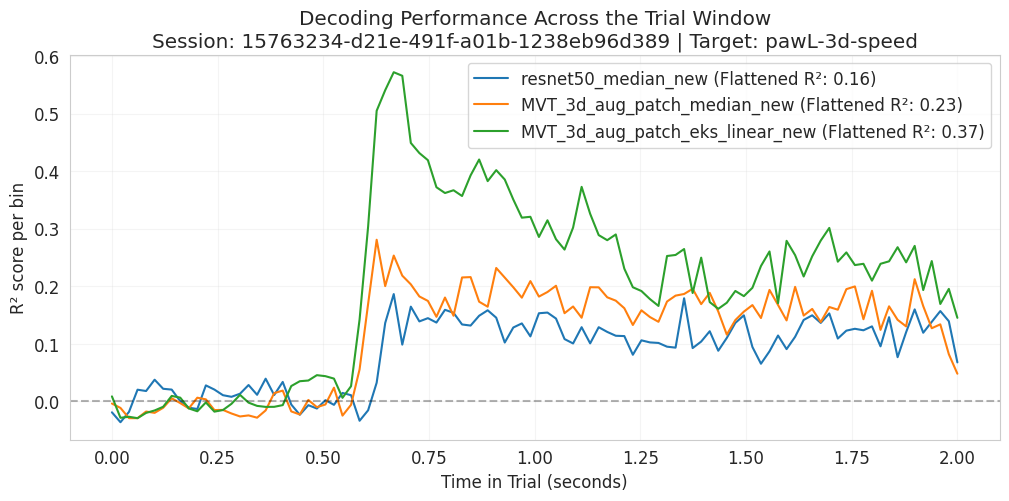

In [72]:
def analyze_per_bin_performance(results, pose_models):
    """
    Calculates and prints/plots R^2 for every time bin (0-100) for each model.
    """
    plt.figure(figsize=(12, 5))
    
    for model_name in pose_models:
        res = results[model_name]
        y_true = res['test_y']     # Shape: [n_trials, n_bins]
        y_pred = res['test_pred']   # Shape: [n_trials, n_bins]
        
        n_bins = y_true.shape[1]
        bin_r2s = []
        
        print(f"\n--- {model_name} Per-Bin R² Summary ---")
        for b in range(n_bins):
            # Calculate R2 for this specific bin across all trials
            r2 = r2_score(y_true[:, b], y_pred[:, b])
            bin_r2s.append(r2)
        
        # Print a few example bins
        print(f"  First bin (0ms):  {bin_r2s[0]:.4f}")
        print(f"  Middle bin (1s):  {bin_r2s[n_bins//2]:.4f}")
        print(f"  Last bin (2s):    {bin_r2s[-1]:.4f}")
        print(f"  Mean of all bins: {np.mean(bin_r2s):.4f}")
        
        # Plot the curve
        plt.plot(np.linspace(0, 2, n_bins), bin_r2s, label=f"{model_name} (Flattened R²: {res['r2']:.2f})")

    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.xlabel("Time in Trial (seconds)")
    plt.ylabel("R² score per bin")
    target_without = target.replace("lightning-pose-", "")
    plt.title(f"Decoding Performance Across the Trial Window\nSession: {eid} | Target: {target_without}")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# Run the analysis
analyze_per_bin_performance(results, pose_models)

In [73]:
results

{'resnet50_median_new': {'test_y': array([[ 0.08634448,  0.19071575,  0.09016812, ...,  0.11352185,
           0.0442964 ,  0.00868268],
         [ 1.62904774,  0.32985378,  1.15222909, ...,  0.90803537,
           1.14982923, -0.66829859],
         [ 0.12578654,  0.21151392,  0.13428233, ...,  0.01516295,
           0.01665746,  0.24983134],
         ...,
         [ 0.00677589,  0.00889583,  0.01184305, ...,  0.02084097,
           0.03208493, -0.01017779],
         [ 0.02622122,  0.05352055,  0.05870071, ...,  0.01783859,
           0.02913367,  0.05088002],
         [ 0.00249746,  0.00987703,  0.0113642 , ...,  0.01197422,
           0.01049752,  0.00580128]]),
  'test_pred': array([[ 0.34398634,  0.22875111,  0.14848144, ...,  0.12063471,
           0.48345906,  1.10038519],
         [ 0.24853443,  0.01346689,  0.12160779, ...,  0.55335345,
           0.42759719,  1.38698299],
         [ 0.28180731,  0.22439205,  0.19033904, ...,  0.12526219,
           0.32736283,  0.85055957],
  

(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: 15763234-d21e-491f-a01b-1238eb96d389 | Window: 1600-2400'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

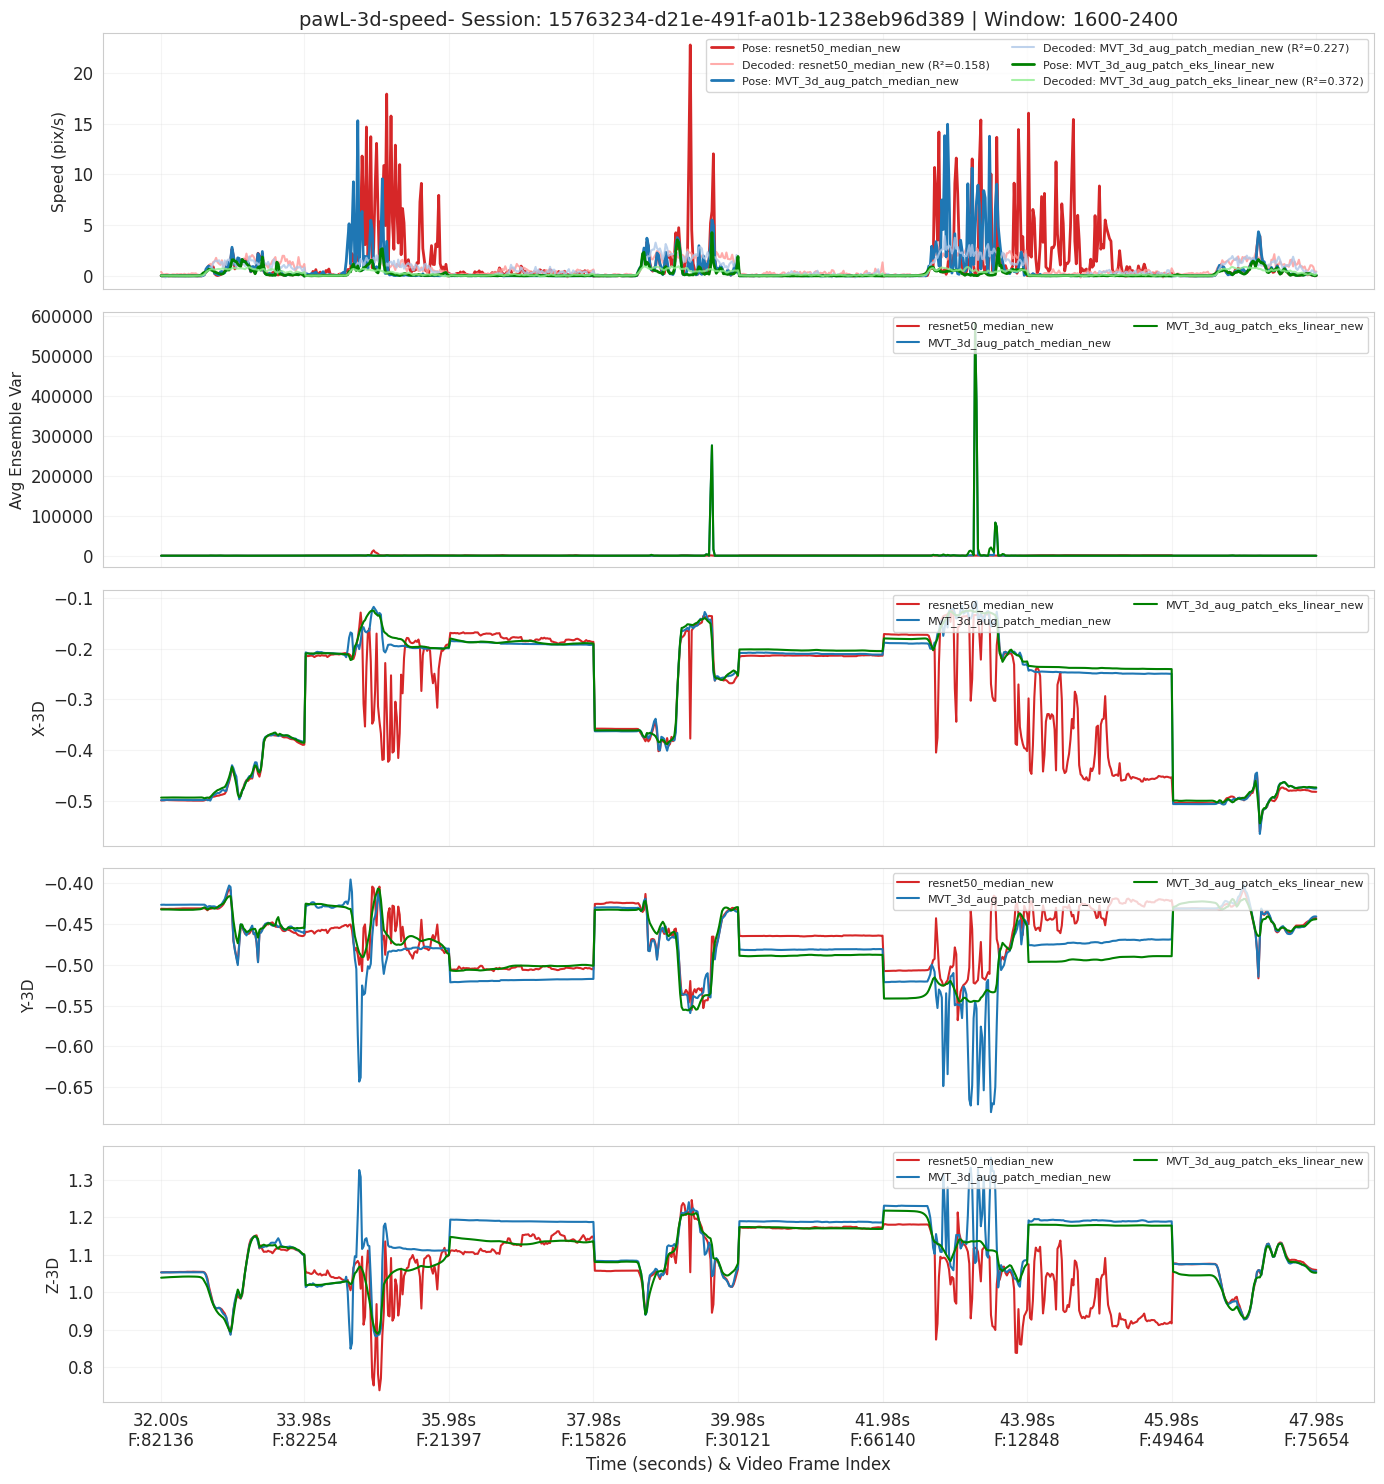

In [88]:
def plot_pose_results(results, pose_models, colors, eid, 
                      plots_to_show=None, 
                      start_time=0, 
                      end_time=800, 
                      sampling_rate=0.02,
                      target=target):
    
    # --- 1. LOAD MAPPING METADATA ---
    common_data_path = Path("/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/ibl_aligned") / eid
    alignment_info = np.load(common_data_path / "alignment_info.npy", allow_pickle=True).item()
    trial_intervals = alignment_info["trial_intervals"] 
    timestamp_file = Path("/media/lenny-aharon/T7/ibl-mouse/timestamps") / f"_ibl_leftCamera.times.{eid}.npy"
    frame_times = np.load(timestamp_file)
    
    orig_trial_ids = results[pose_models[0]]['test_original_trial_ids']
    trial_len_bins = 100 

    # --- 2. UPDATED PLOT CONFIG ---
    # We map the keys we added in the loader to user-friendly labels
    plot_config = {
        'speed': {'label': 'Speed (pix/s)', 'data_key': 'y_flattened'},
        'avg_var': {'label': 'Avg Ensemble Var', 'data_key': 'avg_ens_var_flattened'}, # <--- USE THIS
        'x_3d': {'label': 'X-3D', 'data_key': 'x_3d_flattened'},
        'y_3d': {'label': 'Y-3D', 'data_key': 'y_3d_flattened'},
        'z_3d': {'label': 'Z-3D', 'data_key': 'z_3d_flattened'}
    }

    if plots_to_show is None:
        plots_to_show = list(plot_config.keys())

    num_plots = len(plots_to_show)
    fig, axes = plt.subplots(num_plots, 1, figsize=(14, 3 * num_plots), sharex=True)
    if num_plots == 1: axes = [axes]

    for i, plot_key in enumerate(plots_to_show):
        ax = axes[i]
        config = plot_config.get(plot_key, {'label': plot_key, 'data_key': f"{plot_key}_flattened"})
        
        for pose_model in pose_models:
            res = results[pose_model]
            color_pose = colors[pose_model]['pose']
            
            if plot_key == 'speed':
                ax.plot(res['y_flattened'][start_time:end_time], color=color_pose, linewidth=2, label=f"Pose: {pose_model}")
                ax.plot(res['pred_flattened'][start_time:end_time], color=colors[pose_model]['decoded'], linewidth=1.5, 
                        label=f"Decoded: {pose_model} (R²={res['r2']:.3f})", alpha=0.8)
            else:
                # General plotting for all coordinate and variance keys
                data = res.get(config['data_key'])
                if data is not None:
                    ax.plot(data[start_time:end_time], color=color_pose, label=f"{pose_model}")

        ax.set_ylabel(config['label'], fontsize=11)
        ax.legend(fontsize=8, loc='upper right', ncol=2)
        ax.grid(True, alpha=0.2)

    # --- 3. DYNAMIC X-AXIS WITH VIDEO FRAMES ---
    duration_frames = end_time - start_time
    tick_indices = np.linspace(0, duration_frames - 1, 9, dtype=int)
    time_labels, frame_labels = [], []

    for idx in tick_indices:
        global_idx = start_time + idx
        time_labels.append(f"{(global_idx * sampling_rate):.2f}s")
        
        # trial_idx_in_test = global_idx // trial_len_bins
        # bin_within_trial = global_idx % trial_len_bins
        
        # if trial_idx_in_test < len(orig_trial_ids):
        #     orig_id = orig_trial_ids[trial_idx_in_test]
        #     bin_time = trial_intervals[orig_id][0] + (bin_within_trial * sampling_rate)
        #     video_frame = np.searchsorted(frame_times, bin_time)
        #     frame_labels.append(f"F:{video_frame}")
        # else:
        #     frame_labels.append("")

         # --- Inside the dynamic X-axis loop ---
        trial_idx_in_test = global_idx // trial_len_bins
        bin_within_trial = global_idx % trial_len_bins
        
        # ADD THIS CHECK: Ensure orig_trial_ids is not None
        if orig_trial_ids is not None and trial_idx_in_test < len(orig_trial_ids):
            orig_id = orig_trial_ids[trial_idx_in_test]
            bin_time = trial_intervals[orig_id][0] + (bin_within_trial * sampling_rate)
            video_frame = np.searchsorted(frame_times, bin_time)
            frame_labels.append(f"F:{video_frame}")
        else:
            # Fallback if mapping is missing
            frame_labels.append("")

    axes[-1].set_xticks(tick_indices)
    axes[-1].set_xticklabels([f"{t}\n{f}" for t, f in zip(time_labels, frame_labels)])
    axes[-1].set_xlabel("Time (seconds) & Video Frame Index", fontsize=12)
    
    lightning_pose_without = target.replace("lightning-pose-", "")
    axes[0].set_title(f"{lightning_pose_without}- Session: {eid} | Window: {start_time}-{end_time}", fontsize=14)
    plt.tight_layout()
    return fig, axes

# --- Example of showing the new average variance plots ---
plots_to_show = ['speed', 'avg_var','x_3d', 'y_3d', 'z_3d']
plot_pose_results(results, pose_models, colors, eid, plots_to_show, start_time=1600, end_time=2400)

(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: 15763234-d21e-491f-a01b-1238eb96d389 | Window: 1800-1900'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

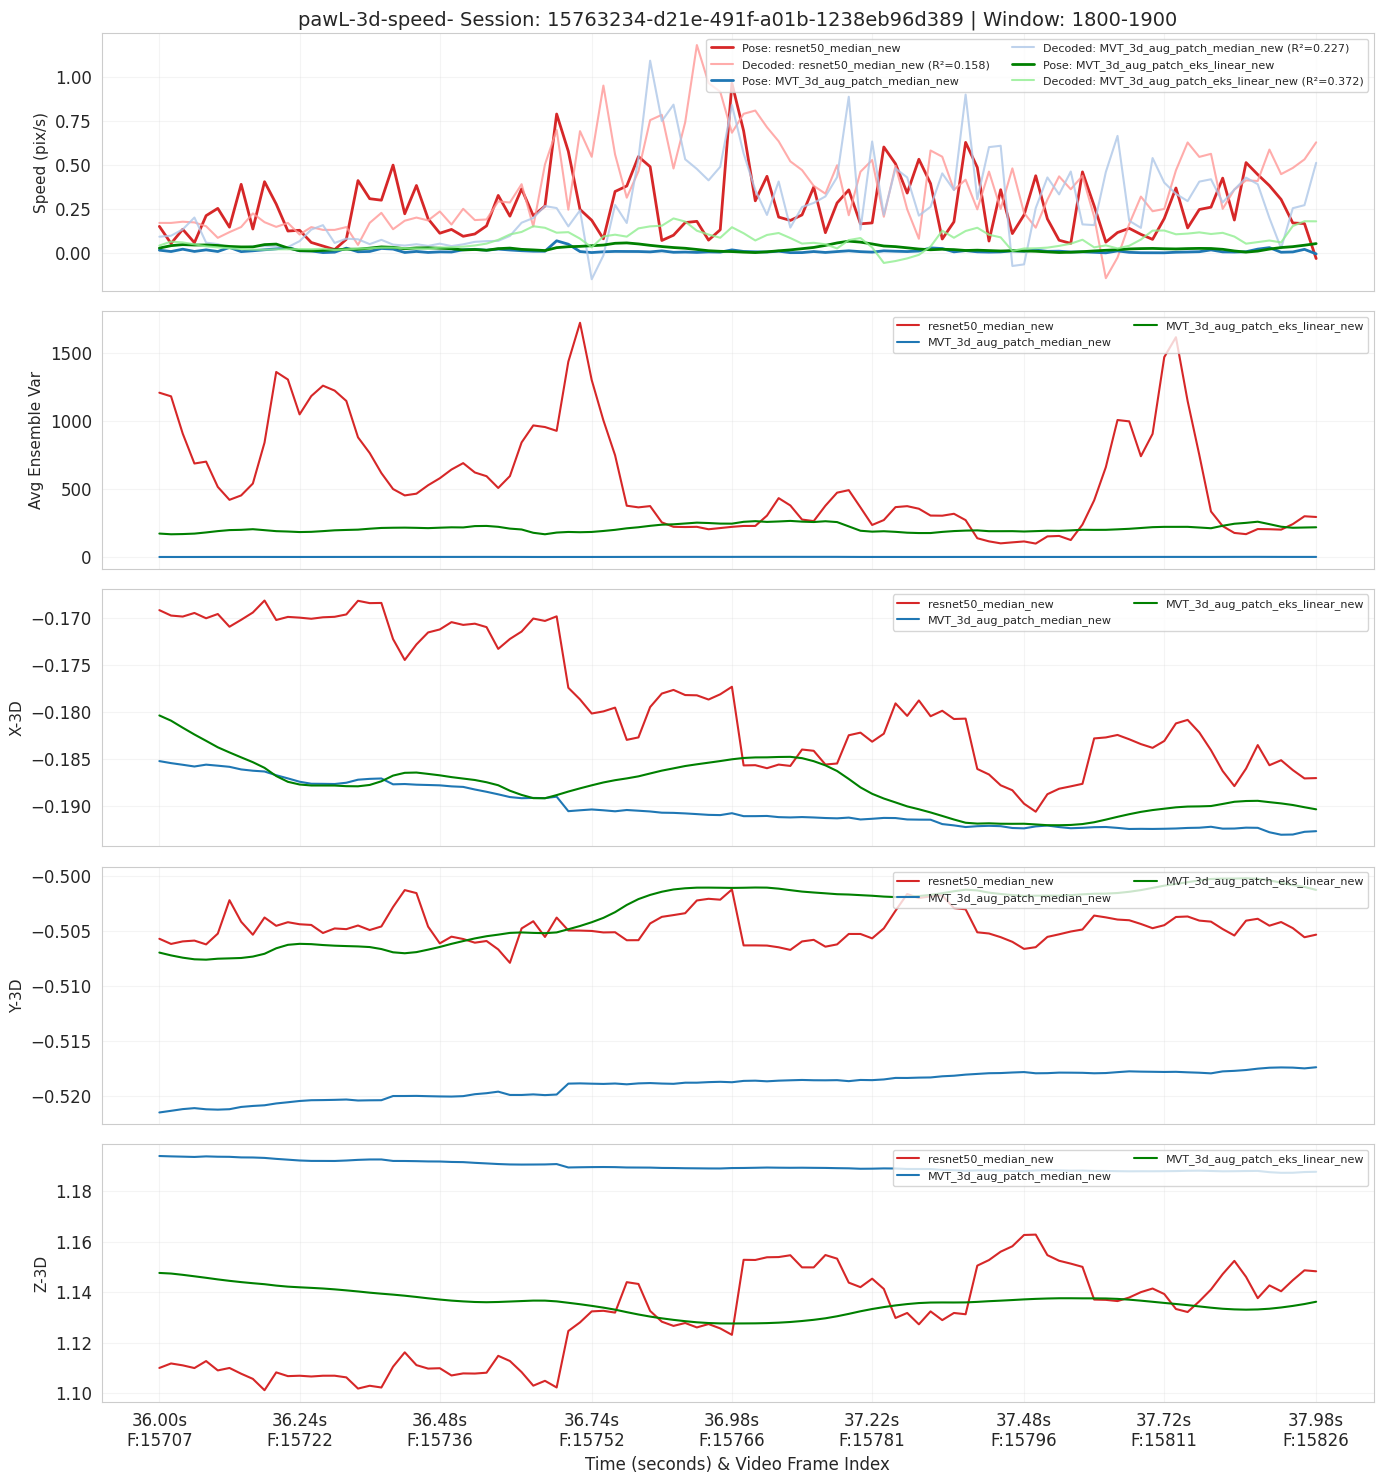

In [94]:
plots_to_show = ['speed','avg_var','x_3d', 'y_3d', 'z_3d']

plot_pose_results(results, pose_models, colors, eid, plots_to_show, start_time=1800, end_time=1900)

In [91]:
pose_models

['resnet50_median_new',
 'MVT_3d_aug_patch_median_new',
 'MVT_3d_aug_patch_eks_linear_new']

In [92]:
resnet=['resnet50_median_new']
mvt = ['MVT_3d_aug_patch_median_new']
mvt_eks = ['MVT_3d_aug_patch_eks_linear_new']



(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: 15763234-d21e-491f-a01b-1238eb96d389 | Window: 100-200'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

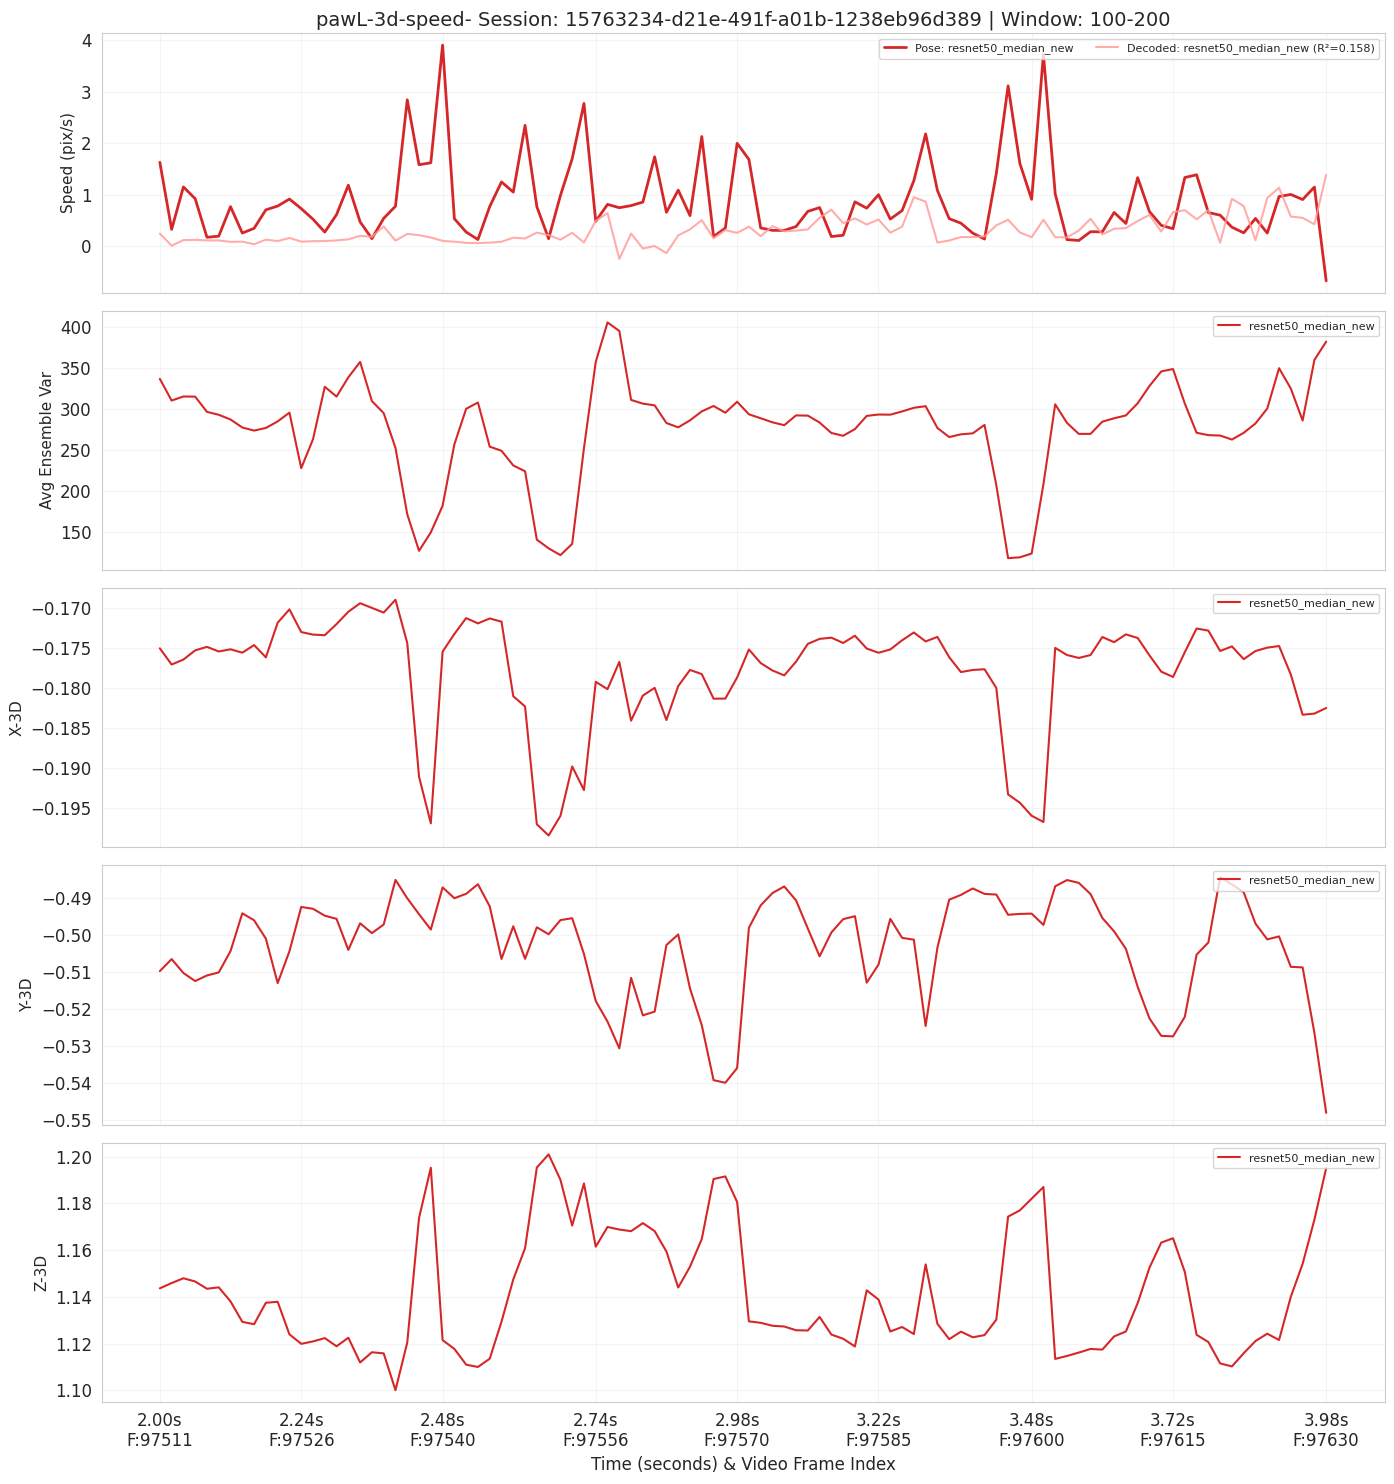

In [78]:
plots_to_show = ['speed','avg_var','x_3d', 'y_3d', 'z_3d']

plot_pose_results(results, resnet, colors, eid, plots_to_show, start_time=100, end_time=200) # was 1600-1700

(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: 15763234-d21e-491f-a01b-1238eb96d389 | Window: 100-200'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

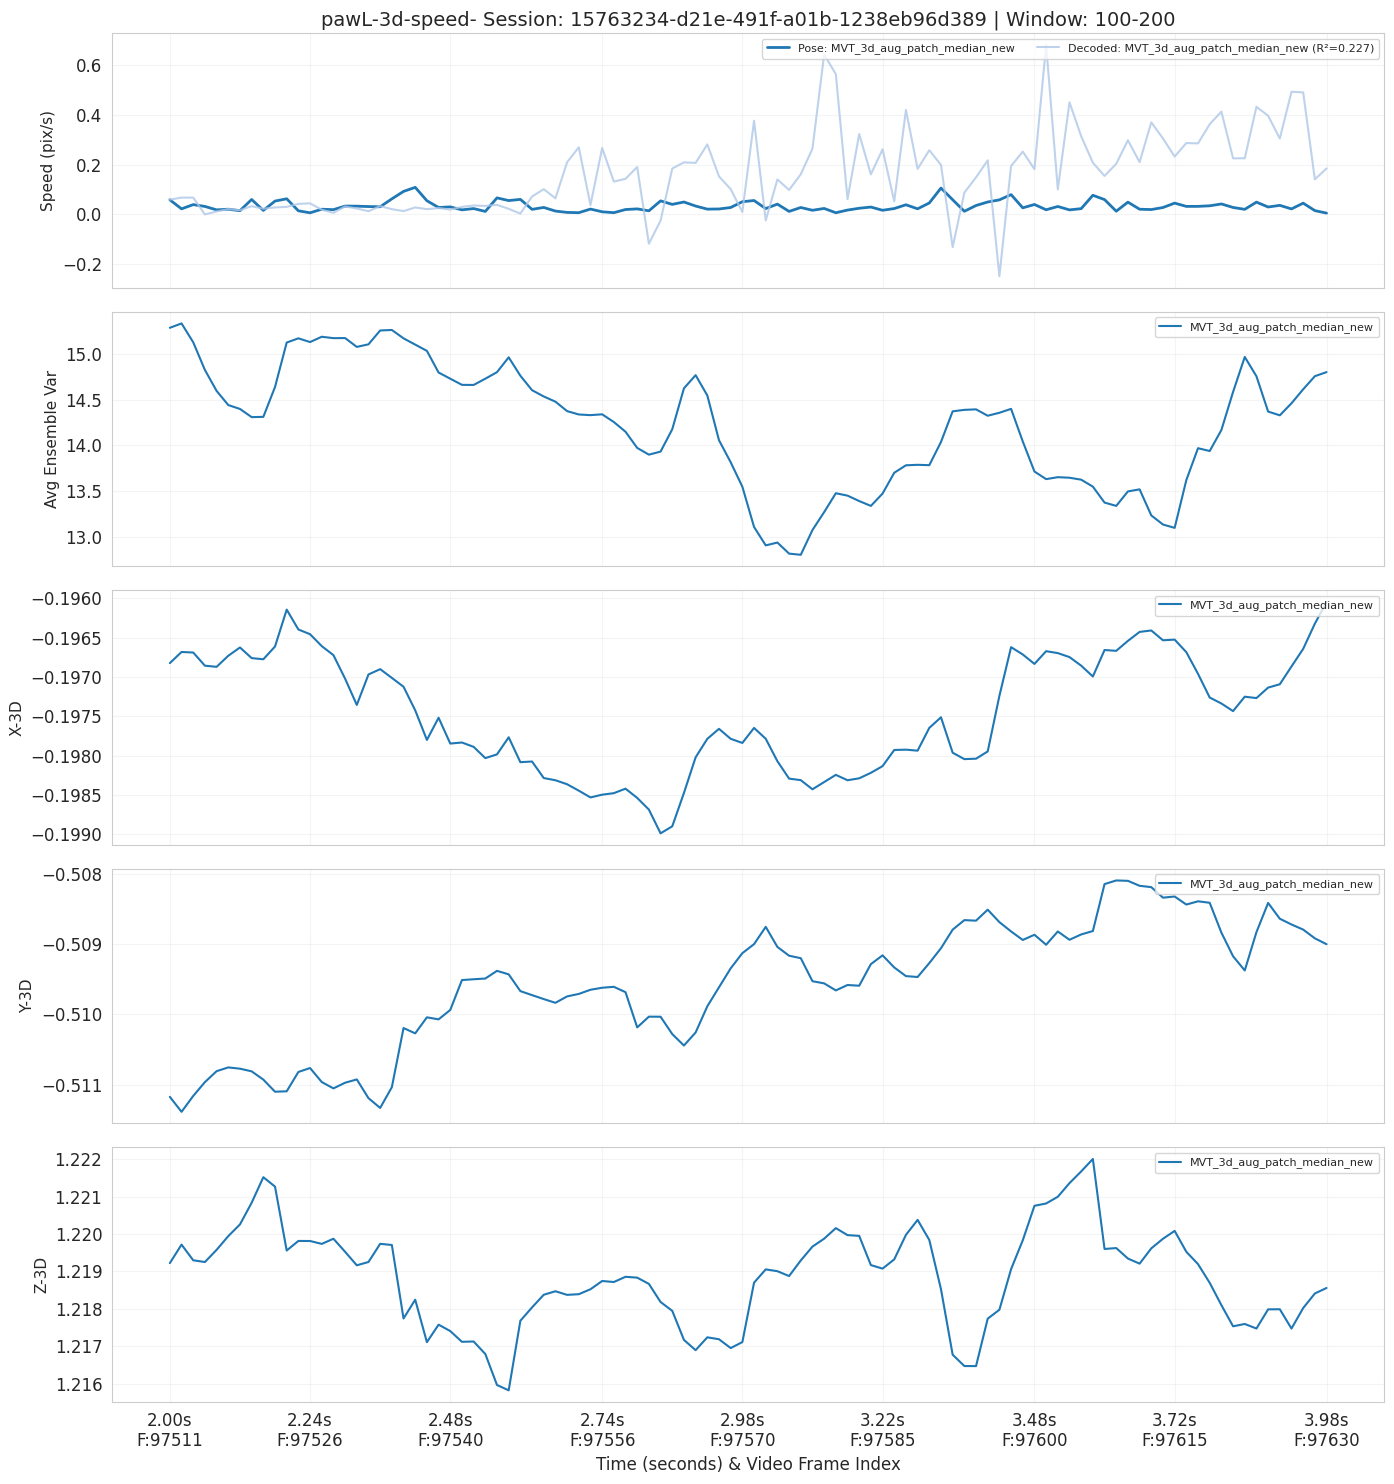

In [79]:
plots_to_show = ['speed','avg_var','x_3d', 'y_3d', 'z_3d']

plot_pose_results(results, mvt, colors, eid, plots_to_show, start_time=100, end_time=200) 

(<Figure size 1400x1500 with 5 Axes>,
 array([<Axes: title={'center': 'pawL-3d-speed- Session: 15763234-d21e-491f-a01b-1238eb96d389 | Window: 100-200'}, ylabel='Speed (pix/s)'>,
        <Axes: ylabel='Avg Ensemble Var'>, <Axes: ylabel='X-3D'>,
        <Axes: ylabel='Y-3D'>,
        <Axes: xlabel='Time (seconds) & Video Frame Index', ylabel='Z-3D'>],
       dtype=object))

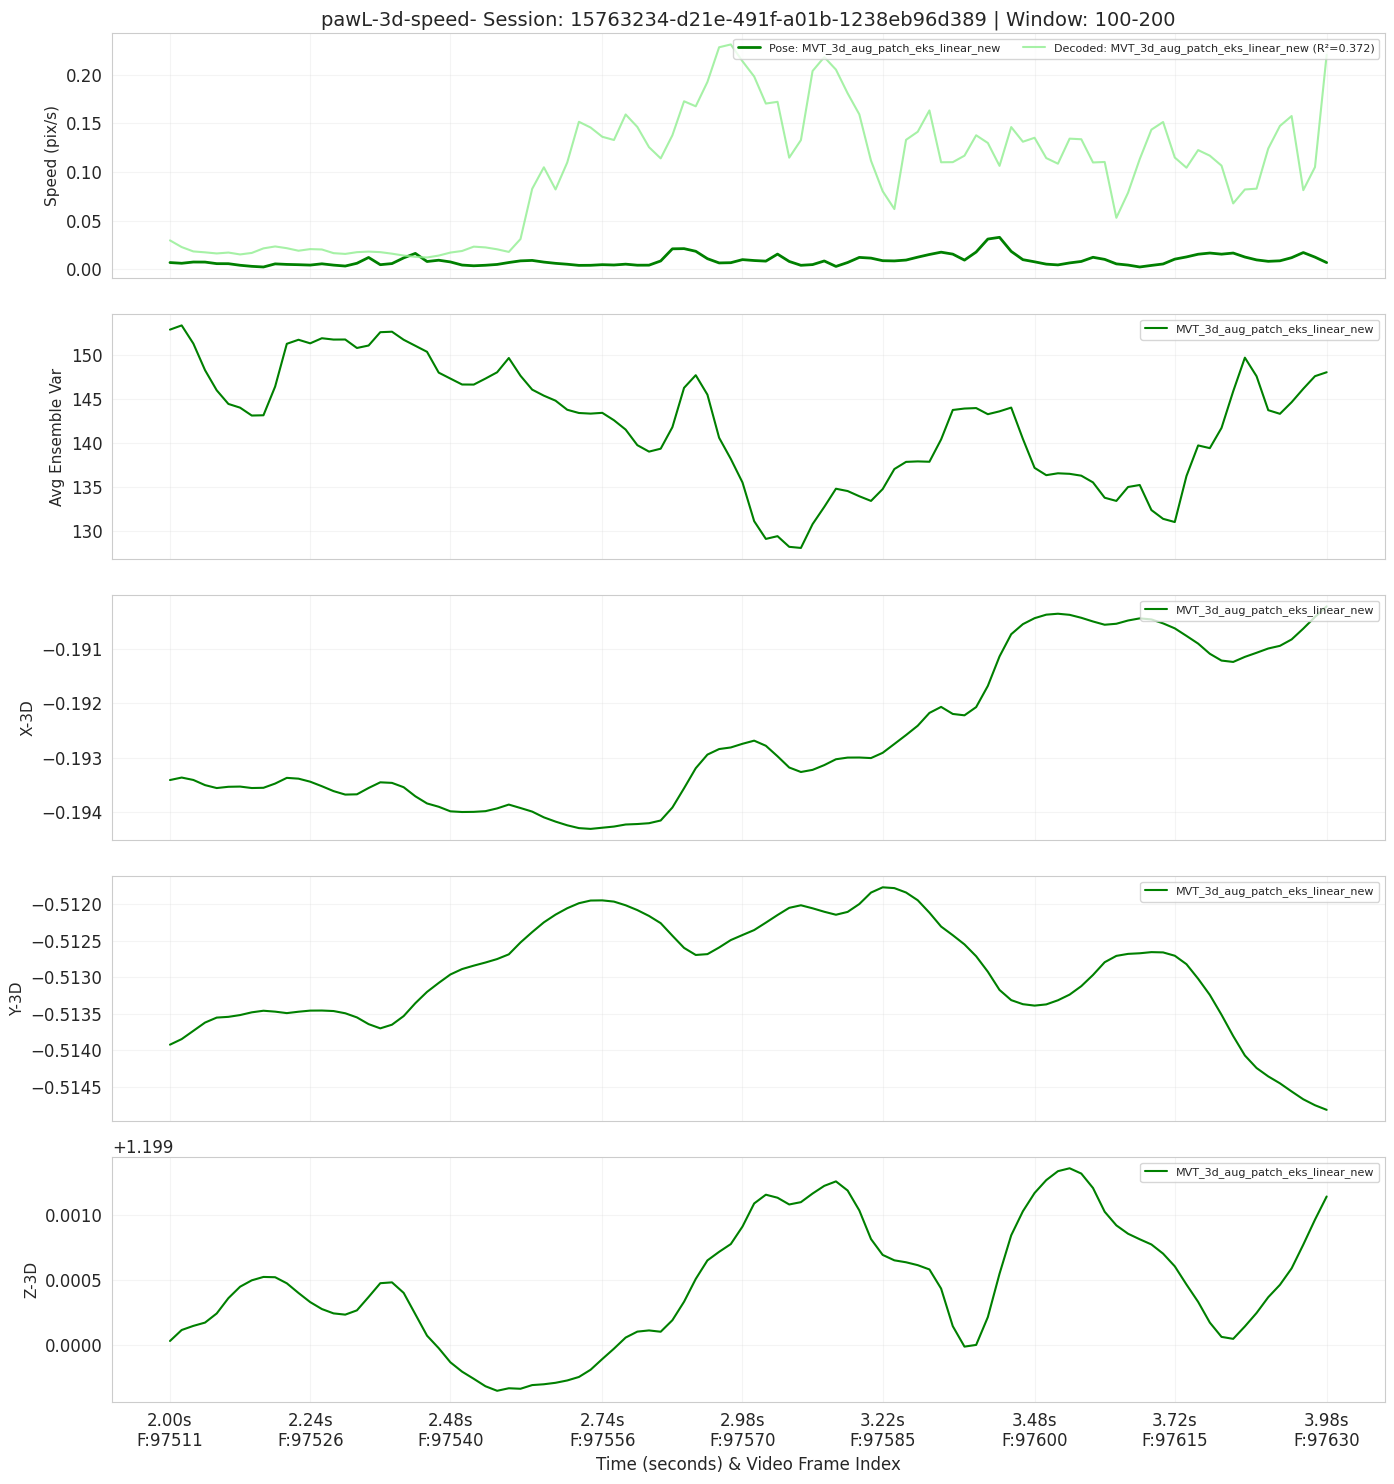

In [80]:
plots_to_show = ['speed','avg_var','x_3d', 'y_3d', 'z_3d']

plot_pose_results(results, mvt_eks, colors, eid, plots_to_show, start_time=100, end_time=200)

/tmp/ipykernel_2949753/1131187078.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved to: /home/lenny-aharon/neural_decoding/notebooks/figures_lenny/pose_results_nature_style.pdf


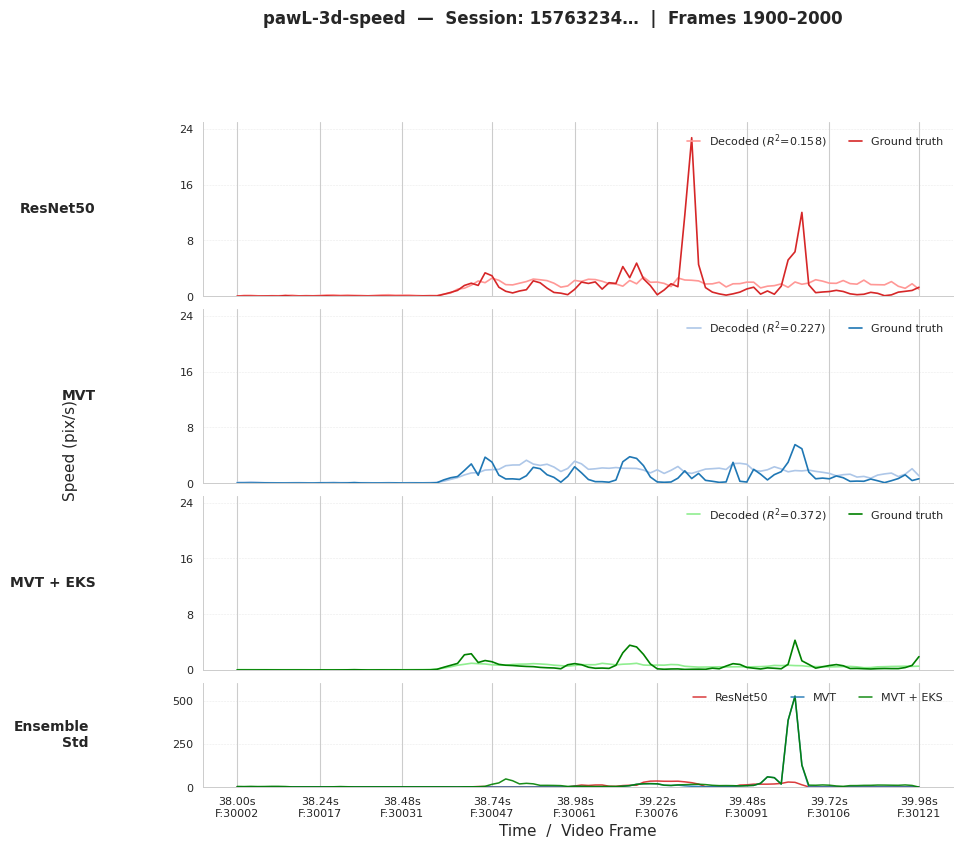

In [96]:
def plot_pose_results_nature(results, pose_models, colors, eid,
                             start_time=0, end_time=800,
                             sampling_rate=0.02, target=target,
                             show_ens_band=False,      # toggle shaded band
                             show_ens_panel=True,      # toggle separate variance panel
                             save_path=None):          # path to save figure as PDF
    """
    Nature Methods-style trace figure.
    Layout: one row per model for speed, optional extra row for ensemble variance.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    from pathlib import Path

    # --- 1. Load mapping metadata ---
    common_data_path = Path("/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/ibl_aligned") / eid
    alignment_info = np.load(common_data_path / "alignment_info.npy", allow_pickle=True).item()
    trial_intervals = alignment_info["trial_intervals"]
    timestamp_file = Path("/media/lenny-aharon/T7/ibl-mouse/timestamps") / f"_ibl_leftCamera.times.{eid}.npy"
    frame_times = np.load(timestamp_file)
    orig_trial_ids = results[pose_models[0]]['test_original_trial_ids']
    trial_len_bins = 100

    model_labels = {
        'resnet50_median_new':             'ResNet50',
        'MVT_3d_aug_patch_median_new':     'MVT',
        'MVT_3d_aug_patch_eks_linear_new': 'MVT + EKS',
        'resnet50_anipose_new':            'ResNet50 + Anipose',
    }

    sl = slice(start_time, end_time)
    n_models = len(pose_models)
    x = np.arange(end_time - start_time)

    # --- 2. Layout: speed rows + optional variance row ---
    n_rows = n_models + (1 if show_ens_panel else 0)
    height_ratios = [2] * n_models + ([1.2] if show_ens_panel else [])

    fig, axes = plt.subplots(
        n_rows, 1,
        figsize=(10, sum(height_ratios) * 1.2),
        sharex=True,
        gridspec_kw={'hspace': 0.08, 'height_ratios': height_ratios}
    )
    if n_rows == 1:
        axes = [axes]

    # Speed axes share y with each other but not with variance panel
    speed_axes = axes[:n_models]

    # --- 3. Global y-limits ---
    all_speed = np.concatenate([
        np.concatenate([results[m]['y_flattened'][sl],
                        results[m]['pred_flattened'][sl]])
        for m in pose_models
    ])
    speed_ylim = (0, np.percentile(all_speed, 100) * 1.1)

    all_ens_std = np.concatenate([
        np.sqrt(np.maximum(results[m]['avg_ens_var_flattened'][sl], 0))
        for m in pose_models
    ])
    ens_ylim = (0, np.percentile(all_ens_std, 100) * 1.15)

    # Link speed axes y-scale manually
    for ax in speed_axes[1:]:
        ax.sharey(speed_axes[0])

    # --- 4. Speed rows ---
    for i, m in enumerate(pose_models):
        ax      = speed_axes[i]
        res     = results[m]
        c_dark  = colors[m]['pose']
        c_light = colors[m]['decoded']
        label   = model_labels.get(m, m)

        truth   = res['y_flattened'][sl]
        pred    = res['pred_flattened'][sl]

        # Optional shaded band
        if show_ens_band:
            ens_std = np.sqrt(np.maximum(res['avg_ens_var_flattened'][sl], 0))
            ax.fill_between(x,
                            pred - 0.5 * ens_std,
                            pred + 0.5 * ens_std,
                            color=c_light, alpha=0.35, linewidth=0, zorder=2)

        ax.plot(x, pred,  color=c_light, linewidth=1.2,
                label=f'Decoded ($R^2$={res["r2"]:.3f})', zorder=3)
        ax.plot(x, truth, color=c_dark,  linewidth=1.2,
                label='Ground truth', zorder=4)

        ax.set_ylabel(label, fontsize=10, fontweight='bold',
                      rotation=0, ha='right', va='center', labelpad=60)
        ax.legend(fontsize=8, frameon=False, loc='upper right',
                  handlelength=1.2, labelspacing=0.3, ncol=2)
        ax.set_ylim(speed_ylim)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.7)
        ax.spines['bottom'].set_linewidth(0.7)
        ax.yaxis.set_major_locator(ticker.MaxNLocator(4, integer=True))
        ax.tick_params(labelsize=8)
        ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.4)

    fig.text(0.01, 0.5, 'Speed (pix/s)', va='center',
             rotation='vertical', fontsize=11)

    # --- 5. Ensemble variance panel (all models overlaid) ---
    if show_ens_panel:
        ax_ens = axes[-1]

        for m in pose_models:
            res     = results[m]
            c_dark  = colors[m]['pose']
            c_light = colors[m]['decoded']
            label   = model_labels.get(m, m)
            ens_std = np.sqrt(np.maximum(res['avg_ens_var_flattened'][sl], 0))

            ax_ens.plot(x, ens_std, color=c_dark, linewidth=1.1,
                        label=label, alpha=0.9, zorder=3)
            # ax_ens.fill_between(x, 0, ens_std,
            #                     color=c_light, alpha=0.2, linewidth=0, zorder=2)

        ax_ens.set_ylim(ens_ylim)
        ax_ens.set_ylabel('Ensemble\nStd', fontsize=10, fontweight='bold',
                          rotation=0, ha='right', va='center', labelpad=60)
        ax_ens.legend(fontsize=8, frameon=False, loc='upper right',
                      handlelength=1.2, labelspacing=0.3, ncol=n_models)
        ax_ens.spines['top'].set_visible(False)
        ax_ens.spines['right'].set_visible(False)
        ax_ens.spines['left'].set_linewidth(0.7)
        ax_ens.spines['bottom'].set_linewidth(0.7)
        ax_ens.yaxis.set_major_locator(ticker.MaxNLocator(3, integer=True))
        ax_ens.tick_params(labelsize=8)
        ax_ens.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.4)

    # --- 6. X-axis ticks on bottom row only ---
    duration_frames = end_time - start_time
    tick_indices = np.linspace(0, duration_frames - 1, 9, dtype=int)
    time_labels, frame_labels = [], []

    for idx in tick_indices:
        global_idx = start_time + idx
        time_labels.append(f"{global_idx * sampling_rate:.2f}s")
        trial_idx_in_test = global_idx // trial_len_bins
        bin_within_trial  = global_idx % trial_len_bins
        if orig_trial_ids is not None and trial_idx_in_test < len(orig_trial_ids):
            orig_id     = orig_trial_ids[trial_idx_in_test]
            bin_time    = trial_intervals[orig_id][0] + (bin_within_trial * sampling_rate)
            video_frame = np.searchsorted(frame_times, bin_time)
            frame_labels.append(f"F:{video_frame}")
        else:
            frame_labels.append("")

    axes[-1].set_xticks(tick_indices)
    axes[-1].set_xticklabels(
        [f"{t}\n{f}" for t, f in zip(time_labels, frame_labels)],
        fontsize=8
    )
    axes[-1].set_xlabel("Time  /  Video Frame", fontsize=11)

    # --- 7. Title ---
    target_clean = target.replace("lightning-pose-", "")
    fig.suptitle(
        f"{target_clean}  —  Session: {eid[:8]}…  |  Frames {start_time}–{end_time}",
        fontsize=12, fontweight='bold', y=1.01
    )

    plt.tight_layout()
    plt.subplots_adjust(left=0.15)
    
    # --- 8. Save figure if path provided ---
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Figure saved to: {save_path}")
    
    return fig, axes


# --- Usage examples ---

# # Clean: no band, no variance panel
# fig, axes = plot_pose_results_nature(
#     results, pose_models, colors, eid,
#     start_time=1600, end_time=1700, target=target,
#     show_ens_band=False, show_ens_panel=False
# )

# With separate variance panel only
fig, axes = plot_pose_results_nature(
    results, pose_models, colors, eid,
    start_time=1900, end_time=2000, target=target,
    show_ens_band=False, show_ens_panel=True,
    save_path="/home/lenny-aharon/neural_decoding/notebooks/figures_lenny/pose_results_nature_style.pdf"
)

# # Both band and panel
# fig, axes = plot_pose_results_nature(
#     results, pose_models, colors, eid,
#     start_time=1600, end_time=1700, target=target,
#     show_ens_band=True, show_ens_panel=True
# )